In [1]:
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install("PLSDAbatch")

Bioconductor version '3.20' is out-of-date; the current release version '3.21'
  is available with R version '4.5'; see https://bioconductor.org/install

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.20 (BiocManager 1.30.26), R 4.4.3 (2025-02-28)

Installing package(s) 'PLSDAbatch'

also installing the dependencies ‘RSpectra’, ‘pracma’, ‘ellipse’, ‘corpcor’, ‘rARPACK’, ‘gsignal’, ‘rgl’, ‘mixOmics’


Warning message in install.packages(...):
“installation of package ‘RSpectra’ had non-zero exit status”
Warning message in install.packages(...):
“installation of package ‘rgl’ had non-zero exit status”
Warning message in install.packages(...):
“installation of package ‘rARPACK’ had non-zero exit status”
Warning message in install.packages(...):
“installation of package ‘gsignal’ had non-zero exit status”
Warning message 

In [2]:
library(pheatmap)
library(vegan)
library(gridExtra)

Loading required package: permute



In [3]:
library(mixOmics)
library(Biobase)
library(TreeSummarizedExperiment)
library(PLSDAbatch)

Loading required package: MASS

Loading required package: lattice

Loading required package: ggplot2

Warning message in rgl.init(initValue, onlyNULL):
“RGL: unable to open X11 display”
Warning message:
“'rgl.init' failed, running with 'rgl.useNULL = TRUE'.”

Loaded mixOmics 6.3.2

Thank you for using mixOmics!

How to apply our methods: http://www.mixOmics.org for some examples.
Questions or comments: email us at mixomics[at]math.univ-toulouse.fr  
Any bugs? https://bitbucket.org/klecao/package-mixomics/issues
Cite us:  citation('mixOmics')


Attaching package: ‘mixOmics’


The following object is masked from ‘package:vegan’:

    pca


Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:gridExtra’:

    combine


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    Filter, Find, Map, Position, Reduce, anyDuplicated, aperm, 

In [4]:
library(PLSDAbatch)

In [72]:
package.version('pheatmap')
package.version('vegan')
package.version('gridExtra')
package.version('mixOmics')
package.version('Biobase')
package.version('PLSDAbatch')

[1] "1.0.13"

[1] "2.7-1"

[1] "2.3"

[1] "6.3.2"

[1] "2.66.0"

[1] "1.2.0"

In [73]:
# Load phyloseq
ps <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_inputs/GP_ps.st.decontam.cleaned.nomock.rds")

In [74]:
library(phyloseq)

# Example: counts matrix from phyloseq
ad.count <- as(otu_table(ps), "matrix")
if (taxa_are_rows(ps)) {
  ad.count <- t(ad.count)  # ensure samples in rows
}
dim(ad.count)

# Metadata (sample_data in phyloseq)
ad.metadata <- as.data.frame(sample_data(ps))

# Batch variable
ad.batch <- factor(ad.metadata$ExtractionDate, 
                   levels = unique(ad.metadata$ExtractionDate))

# Treatment variable
ad.trt <- as.factor(ad.metadata$Haptoglobin_InflamStat)

# Make sure names align with samples
names(ad.batch) <- names(ad.trt) <- rownames(ad.metadata)

# Quick check
table(ad.batch)
table(ad.trt)


[1]   142 21727

ad.batch
12/24/24 12/27/24  1/18/25  1/25/25   2/7/25   2/8/25 
      24       24       23       23       23       25 

ad.trt
Elevated   Normal 
      27      115 

In [75]:
ad.filter.res <- PreFL(data = ad.count)
ad.filter <- ad.filter.res$data.filter
dim(ad.filter)

# zero proportion before filtering
ad.filter.res$zero.prob
# zero proportion after filtering
sum(ad.filter == 0)/(nrow(ad.filter) * ncol(ad.filter))

[1]  142 1634

[1] 0.9941392

[1] 0.9333486

In [76]:
ad.clr <- logratio.transfo(X = ad.filter, logratio = 'CLR', offset = 1) 
class(ad.clr) = 'matrix'

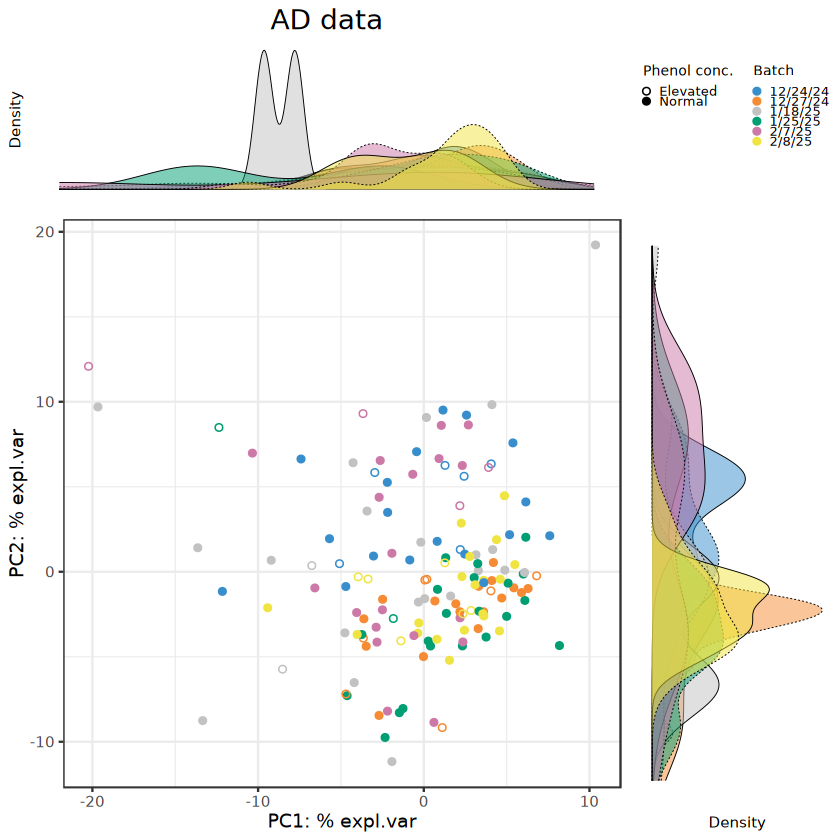

In [77]:
ad.pca.before <- pca(ad.clr, ncomp = 3, scale = TRUE)

Scatter_Density(object = ad.pca.before, batch = ad.batch, trt = ad.trt, 
                title = 'AD data', trt.legend.title = 'Phenol conc.')

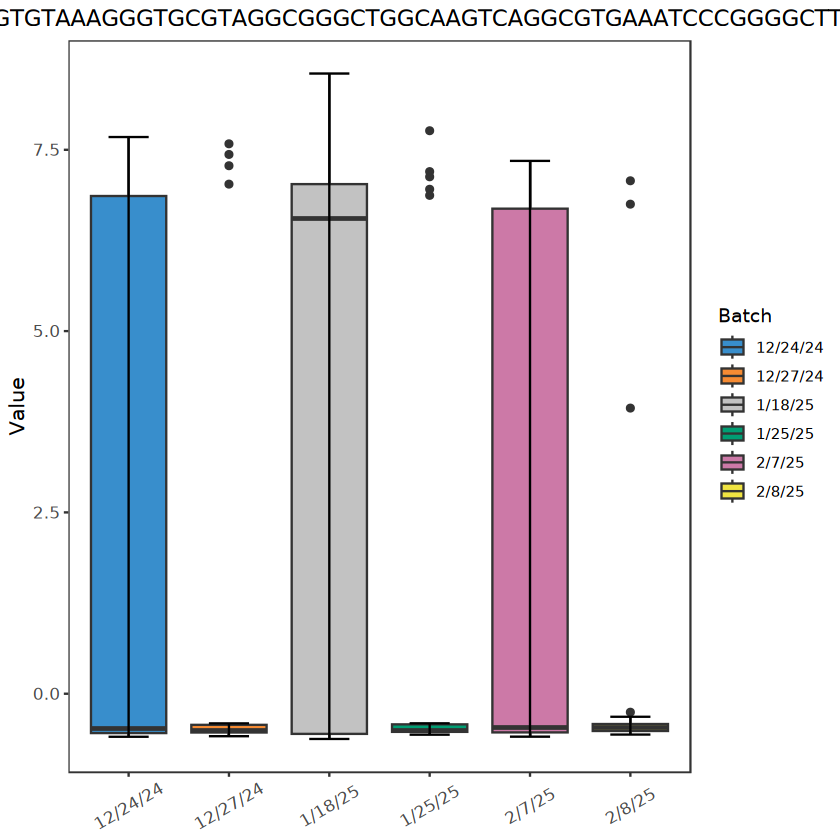

In [78]:
ad.OTU.name <- selectVar(ad.pca.before, comp = 1)$name[1]
ad.OTU_batch <- data.frame(value = ad.clr[,ad.OTU.name], batch = ad.batch)
box_plot(df = ad.OTU_batch, title = paste(ad.OTU.name, '(AD data)'), 
        x.angle = 30)

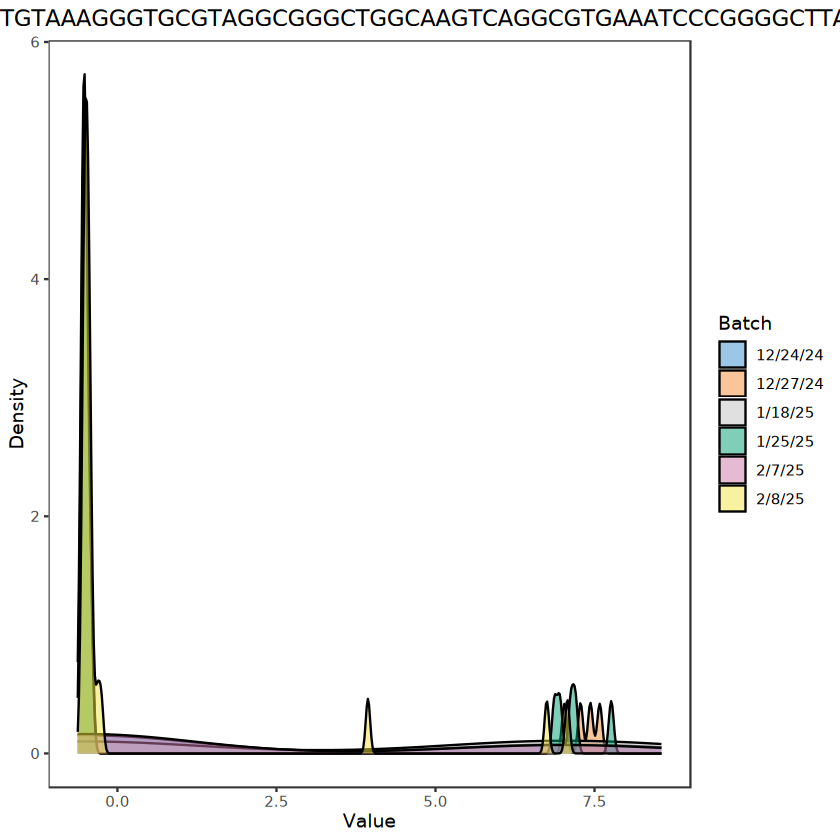

In [79]:
density_plot(df = ad.OTU_batch, title = paste(ad.OTU.name, '(AD data)'))

In [80]:
table(ad.batch)


ad.batch
12/24/24 12/27/24  1/18/25  1/25/25   2/7/25   2/8/25 
      24       24       23       23       23       25 

In [81]:
# reference batch: 12/24/24
ad.batch <- relevel(x = ad.batch, ref = '12/24/24')

ad.OTU.lm <- linear_regres(data = ad.clr[,ad.OTU.name], 
                            trt = ad.trt, batch.fix = ad.batch, 
                            type = 'linear model')
summary(ad.OTU.lm$model$data)


Call:
lm(formula = data[, i] ~ trt + batch.fix)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.9124 -2.0595 -0.8799  3.2769  7.2638 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)        3.23589    0.84513   3.829 0.000196 ***
trtNormal         -1.64240    0.70515  -2.329 0.021335 *  
batch.fix12/27/24 -1.27491    0.93272  -1.367 0.173939    
batch.fix1/18/25   1.69518    0.94933   1.786 0.076399 .  
batch.fix1/25/25  -0.56939    0.94933  -0.600 0.549658    
batch.fix2/7/25   -0.08406    0.94387  -0.089 0.929165    
batch.fix2/8/25   -1.68785    0.92292  -1.829 0.069634 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.229 on 135 degrees of freedom
Multiple R-squared:  0.1246,	Adjusted R-squared:  0.08566 
F-statistic: 3.202 on 6 and 135 DF,  p-value: 0.005701


In [82]:
# reference batch: 2/8/25
ad.batch <- relevel(x = ad.batch, ref = '2/8/25')

ad.OTU.lm <- linear_regres(data = ad.clr[,ad.OTU.name], 
                            trt = ad.trt, batch.fix = ad.batch, 
                            type = 'linear model')
summary(ad.OTU.lm$model$data)


Call:
lm(formula = data[, i] ~ trt + batch.fix)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.9124 -2.0595 -0.8799  3.2769  7.2638 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)         1.5480     0.8393   1.845 0.067300 .  
trtNormal          -1.6424     0.7051  -2.329 0.021335 *  
batch.fix12/24/24   1.6878     0.9229   1.829 0.069634 .  
batch.fix12/27/24   0.4129     0.9236   0.447 0.655524    
batch.fix1/18/25    3.3830     0.9393   3.602 0.000443 ***
batch.fix1/25/25    1.1185     0.9393   1.191 0.235841    
batch.fix2/7/25     1.6038     0.9342   1.717 0.088330 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.229 on 135 degrees of freedom
Multiple R-squared:  0.1246,	Adjusted R-squared:  0.08566 
F-statistic: 3.202 on 6 and 135 DF,  p-value: 0.005701


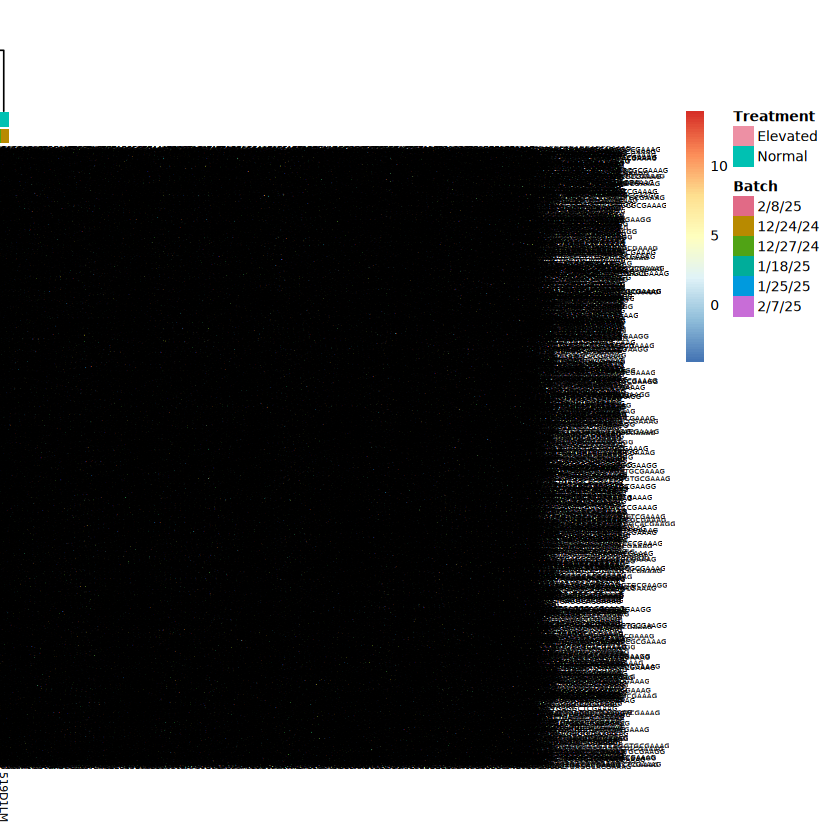

In [83]:
library(pheatmap)

# ensure factors are clean
ad.batch <- droplevels(ad.batch)
ad.trt   <- droplevels(ad.trt)

# build colors safely (no mixOmics needed)
nbatch <- nlevels(ad.batch)
ntrt   <- nlevels(ad.trt)

batch_cols <- grDevices::hcl.colors(nbatch, palette = "Dark3")
trt_cols   <- grDevices::hcl.colors(ntrt,   palette = "Set2")

names(batch_cols) <- levels(ad.batch)
names(trt_cols)   <- levels(ad.trt)

ad.anno_colors <- list(Batch = batch_cols, Treatment = trt_cols)

# make sure annotation rows match heatmap columns
ad.anno_col <- data.frame(Batch = ad.batch, Treatment = ad.trt)
rownames(ad.anno_col) <- rownames(ad.metadata)  # or: colnames(ad.clr.ss)
stopifnot(identical(rownames(ad.anno_col), colnames(ad.clr.ss)))

# plot
pheatmap(
  ad.clr.ss,
  cluster_rows = FALSE,
  fontsize_row = 4,
  fontsize_col = 6,
  fontsize = 8,
  clustering_distance_rows = "euclidean",
  clustering_method = "ward.D",
  treeheight_row = 30,
  annotation_col = ad.anno_col,
  annotation_colors = ad.anno_colors,
  border_color = NA,
  main = "AD data - Scaled"
)


In [84]:
# AD data
ad.factors.df <- data.frame(trt = ad.trt, batch = ad.batch)
class(ad.clr) <- 'matrix'
ad.rda.before <- varpart(ad.clr, ~ trt, ~ batch, 
                        data = ad.factors.df, scale = TRUE)
ad.rda.before$part$indfract


,Df,R.squared,Adj.R.squared,Testable
,<dbl>,<lgl>,<dbl>,<lgl>
[a] = X1|X2,1,NA,6.974923e-04,TRUE
[b] = X2|X1,5,NA,4.391873e-03,TRUE
[c],0,NA,-9.253769e-05,FALSE
[d] = Residuals,NA,NA,9.950032e-01,FALSE


In [85]:
# estimate the number of treatment components
ad.trt.tune <- plsda(X = ad.clr, Y = ad.trt, ncomp = 5)
ad.trt.tune$prop_expl_var #1

NULL

In [86]:
# estimate the number of batch components
ad.batch.tune <- PLSDA_batch(X = ad.clr, 
                            Y.trt = ad.trt, Y.bat = ad.batch,
                            ncomp.trt = 1, ncomp.bat = 10)
ad.batch.tune$explained_variance.bat #4
sum(ad.batch.tune$explained_variance.bat$Y[seq_len(4)])

$X
     comp 1      comp 2      comp 3      comp 4      comp 5      comp 6 
0.012658701 0.010807802 0.009885615 0.008905917 0.007554265 0.009816753 
     comp 7      comp 8      comp 9     comp 10 
0.008380069 0.009484554 0.009068798 0.007909521 

$Y
   comp 1    comp 2    comp 3    comp 4    comp 5    comp 6    comp 7    comp 8 
0.1997145 0.1997987 0.1993848 0.2013423 0.1997597 0.1999015 0.2000753 0.1993175 
   comp 9   comp 10 
0.1989751 0.1962993

[1] 0.8002403

In [87]:
## -----------------------------------------------------------------------------
ad.PLSDA_batch.res <- PLSDA_batch(X = ad.clr, 
                                Y.trt = ad.trt, Y.bat = ad.batch,
                                ncomp.trt = 1, ncomp.bat = 4)
ad.PLSDA_batch <- ad.PLSDA_batch.res$X.nobatch

In [88]:
## ----eval = F-----------------------------------------------------------------
# # estimate the number of variables to select per treatment component
 set.seed(777)
 ad.test.keepX = c(seq(1, 10, 1), seq(20, 100, 10),
                 seq(150, 231, 50), 231)
 ad.trt.tune.v <- tune.splsda(X = ad.clr, Y = ad.trt,
                             ncomp = 1, test.keepX = ad.test.keepX,
                             validation = 'Mfold', folds = 4,
                             nrepeat = 50)
ad.trt.tune.v$choice.keepX #100


comp 1 
  |======================================================================| 100%


comp1 
   20

In [89]:
# estimate the number of batch components
ad.batch.tune <- PLSDA_batch(X = ad.clr, 
                            Y.trt = ad.trt, Y.bat = ad.batch,
                            ncomp.trt = 1, keepX.trt = 100,
                            ncomp.bat = 10)
ad.batch.tune$explained_variance.bat #4
sum(ad.batch.tune$explained_variance.bat$Y[seq_len(4)])


$X
     comp 1      comp 2      comp 3      comp 4      comp 5      comp 6 
0.012849268 0.010836800 0.009833637 0.008948012 0.007593499 0.009915497 
     comp 7      comp 8      comp 9     comp 10 
0.009295962 0.009177058 0.008231780 0.007902115 

$Y
   comp 1    comp 2    comp 3    comp 4    comp 5    comp 6    comp 7    comp 8 
0.1997334 0.1998295 0.1993795 0.2013338 0.1997238 0.1994958 0.2000199 0.1962874 
   comp 9   comp 10 
0.1989719 0.2013836

[1] 0.8002762

In [90]:

## -----------------------------------------------------------------------------
ad.sPLSDA_batch.res <- PLSDA_batch(X = ad.clr, 
                                Y.trt = ad.trt, Y.bat = ad.batch,
                                ncomp.trt = 1, keepX.trt = 100,
                                ncomp.bat = 4)
ad.sPLSDA_batch <- ad.sPLSDA_batch.res$X.nobatch

In [91]:
ad.pca.before <- pca(ad.clr, ncomp = 3, scale = TRUE)
ad.pca.PLSDA_batch <- pca(ad.PLSDA_batch, ncomp = 3, scale = TRUE)
ad.pca.sPLSDA_batch <- pca(ad.sPLSDA_batch, ncomp = 3, scale = TRUE)

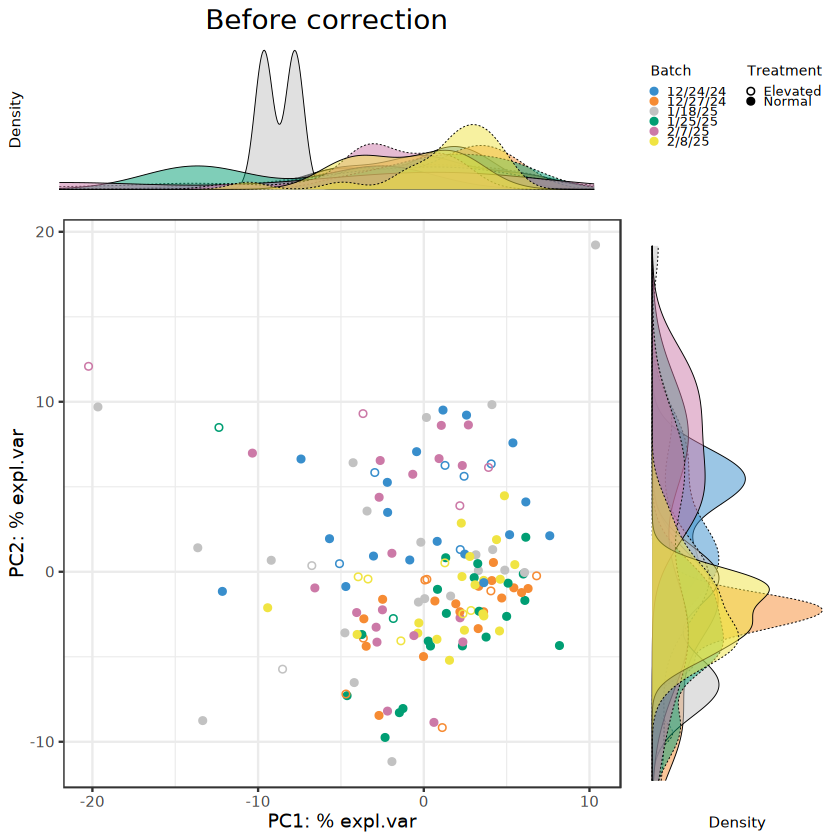

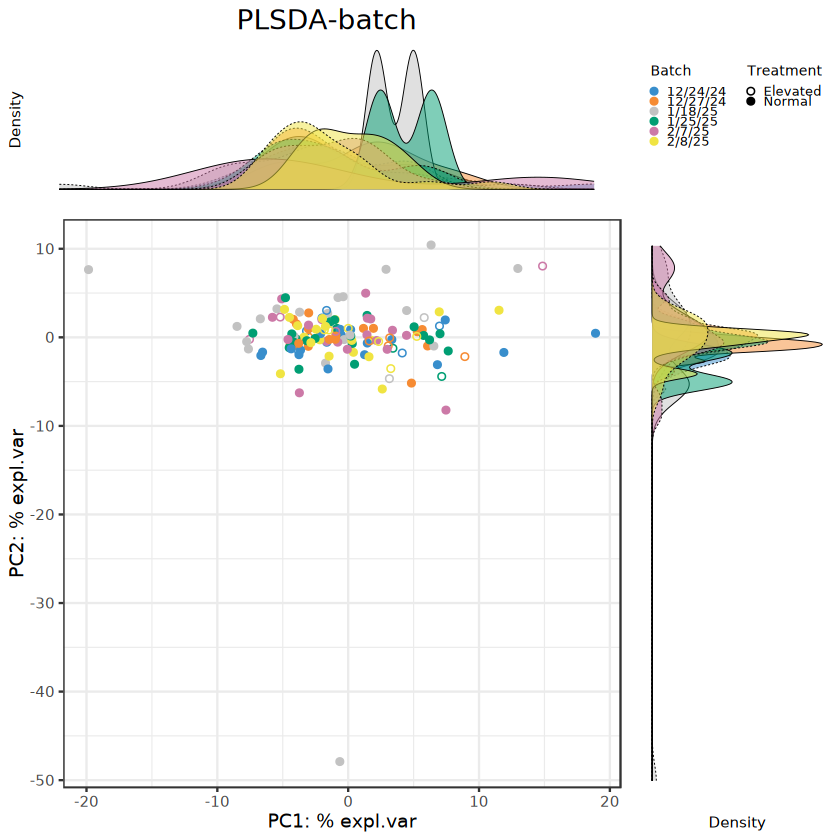

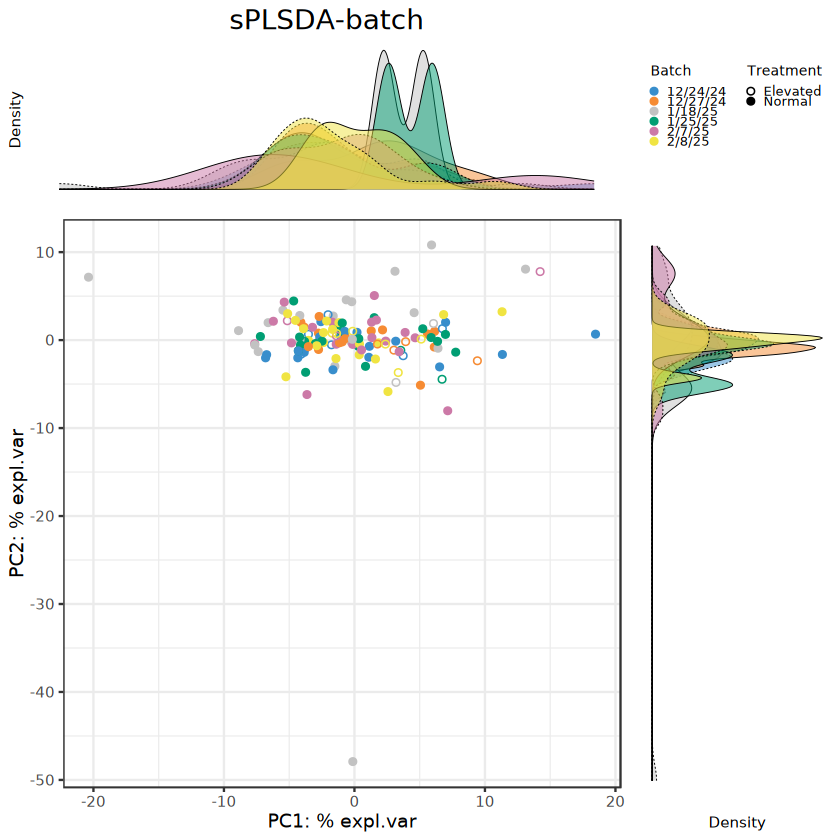

In [92]:
# order batches
ad.batch = factor(ad.metadata$ExtractionDate, 
                levels = unique(ad.metadata$ExtractionDate))

ad.pca.before.plot <- Scatter_Density(object = ad.pca.before, 
                                    batch = ad.batch, 
                                    trt = ad.trt, 
                                    title = 'Before correction')
ad.pca.PLSDA_batch.plot <- Scatter_Density(object = ad.pca.PLSDA_batch, 
                                        batch = ad.batch, 
                                        trt = ad.trt, 
                                        title = 'PLSDA-batch')
ad.pca.sPLSDA_batch.plot <- Scatter_Density(object = ad.pca.sPLSDA_batch, 
                                            batch = ad.batch, 
                                            trt = ad.trt, 
                                            title = 'sPLSDA-batch')

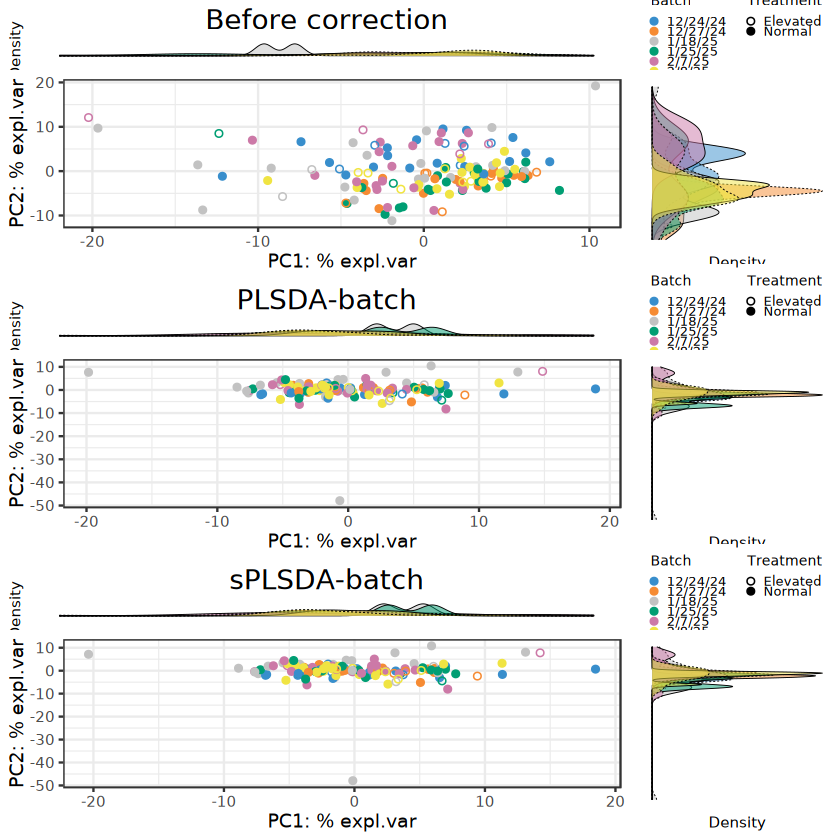

In [93]:
## ----ADpca, fig.height = 12, fig.width = 6, out.width = '80%', echo = FALSE, fig.align = 'center', fig.cap = 'The PCA sample plots with densities before and after batch effect correction in the AD data.'----
grid.arrange(ad.pca.before.plot, 
            ad.pca.PLSDA_batch.plot, 
            ad.pca.sPLSDA_batch.plot, ncol = 1)

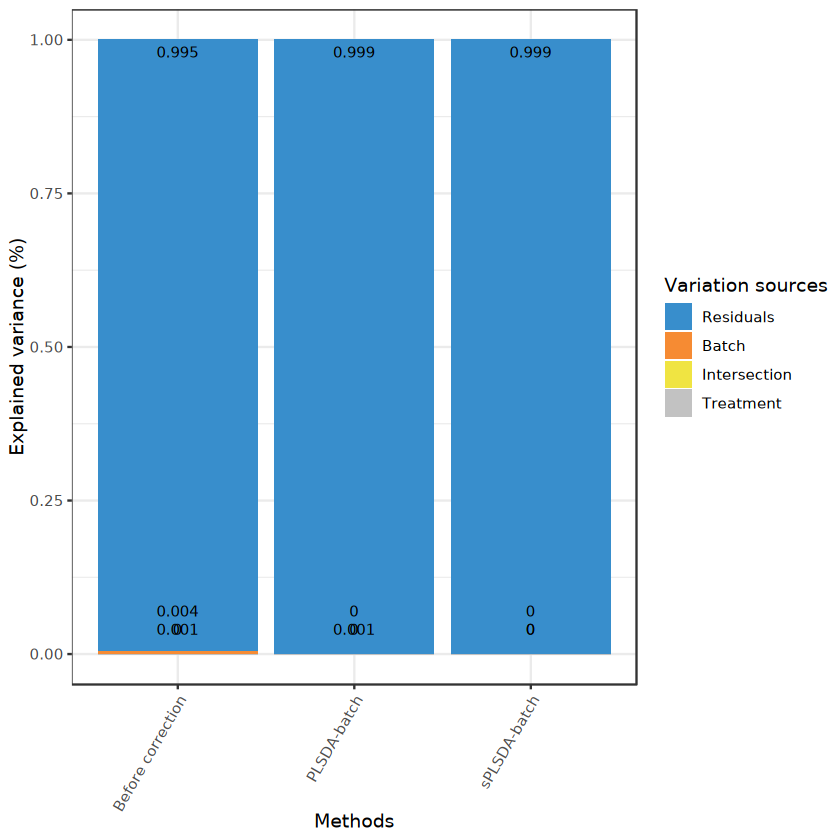

In [94]:
## ----ADprda, fig.height = 6, fig.width = 4, out.width = '80%', fig.align = 'center', fig.cap = 'Global explained variance before and after batch effect correction for the AD data.'----
# AD data
ad.corrected.list <- list(`Before correction` = ad.clr, 
                        `PLSDA-batch` = ad.PLSDA_batch, 
                        `sPLSDA-batch` = ad.sPLSDA_batch)

ad.prop.df <- data.frame(Treatment = NA, Batch = NA, 
                        Intersection = NA, 
                        Residuals = NA) 
for(i in seq_len(length(ad.corrected.list))){
    rda.res = varpart(ad.corrected.list[[i]], ~ trt, ~ batch,
                    data = ad.factors.df, scale = TRUE)
    ad.prop.df[i, ] <- rda.res$part$indfract$Adj.R.squared}

rownames(ad.prop.df) = names(ad.corrected.list)

ad.prop.df <- ad.prop.df[, c(1,3,2,4)]

ad.prop.df[ad.prop.df < 0] = 0
ad.prop.df <- as.data.frame(t(apply(ad.prop.df, 1, 
                                    function(x){x/sum(x)})))
partVar_plot(prop.df = ad.prop.df)

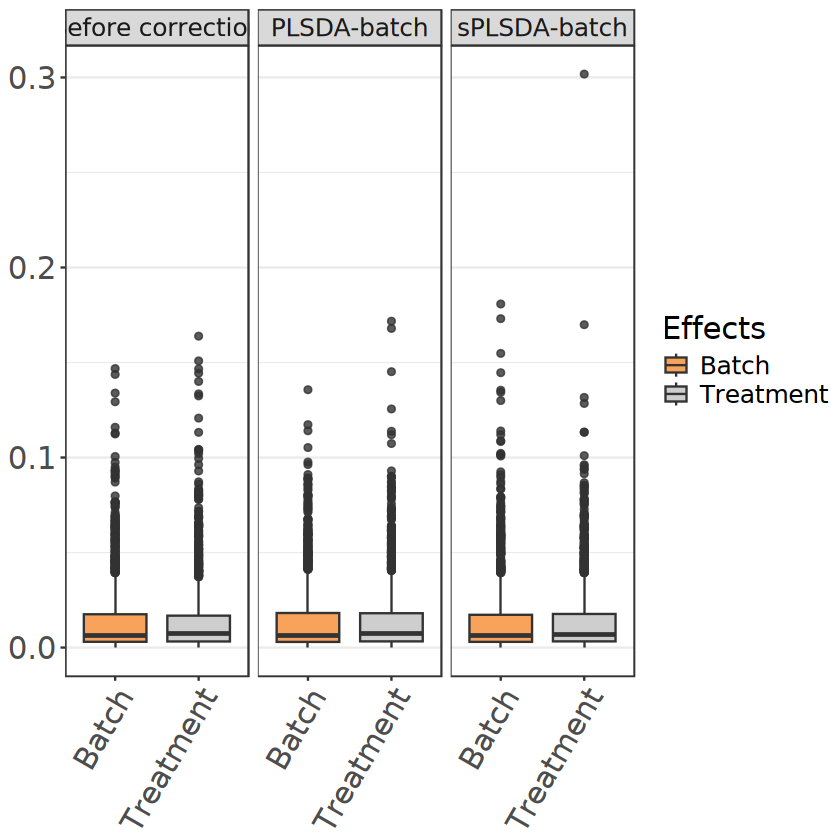

In [95]:
## ----ADr21, fig.height = 6, fig.width = 8, out.width = '100%', fig.align = 'center', fig.cap = 'AD study: $R^2$ values for each microbial variable before and after batch effect correction.'----
# AD data
# scale
ad.corr_scale.list <- lapply(ad.corrected.list, 
                            function(x){apply(x, 2, scale)})

ad.r_values.list <- list()
for(i in seq_len(length(ad.corr_scale.list))){
    ad.r_values <- data.frame(trt = NA, batch = NA)
    for(c in seq_len(ncol(ad.corr_scale.list[[i]]))){
        ad.fit.res.trt <- lm(ad.corr_scale.list[[i]][,c] ~ ad.trt)
        ad.r_values[c,1] <- summary(ad.fit.res.trt)$r.squared
        ad.fit.res.batch <- lm(ad.corr_scale.list[[i]][,c] ~ ad.batch)
        ad.r_values[c,2] <- summary(ad.fit.res.batch)$r.squared
    }
    ad.r_values.list[[i]] <- ad.r_values
}
names(ad.r_values.list) <- names(ad.corr_scale.list)

ad.boxp.list <- list()
for(i in seq_len(length(ad.r_values.list))){
    ad.boxp.list[[i]] <- 
        data.frame(r2 = c(ad.r_values.list[[i]][ ,'trt'],
                        ad.r_values.list[[i]][ ,'batch']), 
                    Effects = as.factor(rep(c('Treatment','Batch')
                                        )))
}
names(ad.boxp.list) <- names(ad.r_values.list)

ad.r2.boxp <- rbind(ad.boxp.list$`Before correction`,
                    ad.boxp.list$removeBatchEffect,
                    ad.boxp.list$ComBat,
                    ad.boxp.list$`PLSDA-batch`,
                    ad.boxp.list$`sPLSDA-batch`,
                    ad.boxp.list$`Percentile Normalisation`,
                    ad.boxp.list$RUVIII)

ad.r2.boxp$methods <- rep(c('Before correction', 'PLSDA-batch', 'sPLSDA-batch')
                        )

ad.r2.boxp$methods <- factor(ad.r2.boxp$methods, 
                            levels = unique(ad.r2.boxp$methods))

ggplot(ad.r2.boxp, aes(x = Effects, y = r2, fill = Effects)) +
    geom_boxplot(alpha = 0.80) +
    theme_bw() + 
    theme(text = element_text(size = 18),
            axis.title.x = element_blank(),
            axis.title.y = element_blank(),
            axis.text.x = element_text(angle = 60, hjust = 1, size = 18),
            axis.text.y = element_text(size = 18),
            panel.grid.minor.x = element_blank(),
            panel.grid.major.x = element_blank(),
            legend.position = "right") + facet_grid( ~ methods) + 
    scale_fill_manual(values=pb_color(c(12,14))) 

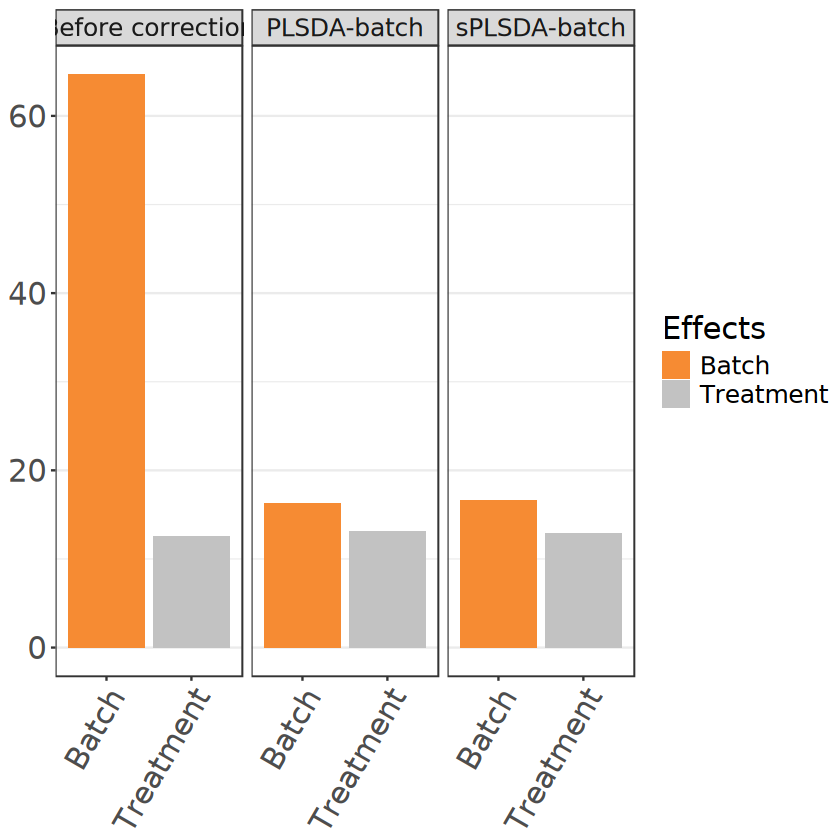

In [96]:
## ----ADr22, fig.height = 6, fig.width = 8, out.width = '100%', fig.align = 'center', fig.cap = 'AD study: the sum of $R^2$ values for each microbial variable before and after batch effect correction.'----
##################################
ad.barp.list <- list()
for(i in seq_len(length(ad.r_values.list))){
    ad.barp.list[[i]] <- data.frame(r2 = c(sum(ad.r_values.list[[i]][ ,'trt']),
                                        sum(ad.r_values.list[[i]][ ,'batch'])), 
                                    Effects = c('Treatment','Batch'))
}
names(ad.barp.list) <- names(ad.r_values.list)

ad.r2.barp <- rbind(ad.barp.list$`Before correction`,
                    ad.barp.list$removeBatchEffect,
                    ad.barp.list$ComBat,
                    ad.barp.list$`PLSDA-batch`,
                    ad.barp.list$`sPLSDA-batch`,
                    ad.barp.list$`Percentile Normalisation`,
                    ad.barp.list$RUVIII)


ad.r2.barp$methods <- rep(c('Before correction', 'PLSDA-batch', 'sPLSDA-batch'),
                        each = 2)

ad.r2.barp$methods <- factor(ad.r2.barp$methods, 
                            levels = unique(ad.r2.barp$methods))


ggplot(ad.r2.barp, aes(x = Effects, y = r2, fill = Effects)) +
    geom_bar(stat="identity") + 
    theme_bw() + 
    theme(text = element_text(size = 18),
            axis.title.x = element_blank(),
            axis.title.y = element_blank(),
            axis.text.x = element_text(angle = 60, hjust = 1, size = 18),
            axis.text.y = element_text(size = 18),
            panel.grid.minor.x = element_blank(),
            panel.grid.major.x = element_blank(),
            legend.position = "right") + facet_grid( ~ methods) + 
    scale_fill_manual(values=pb_color(c(12,14)))


Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_text()`).”


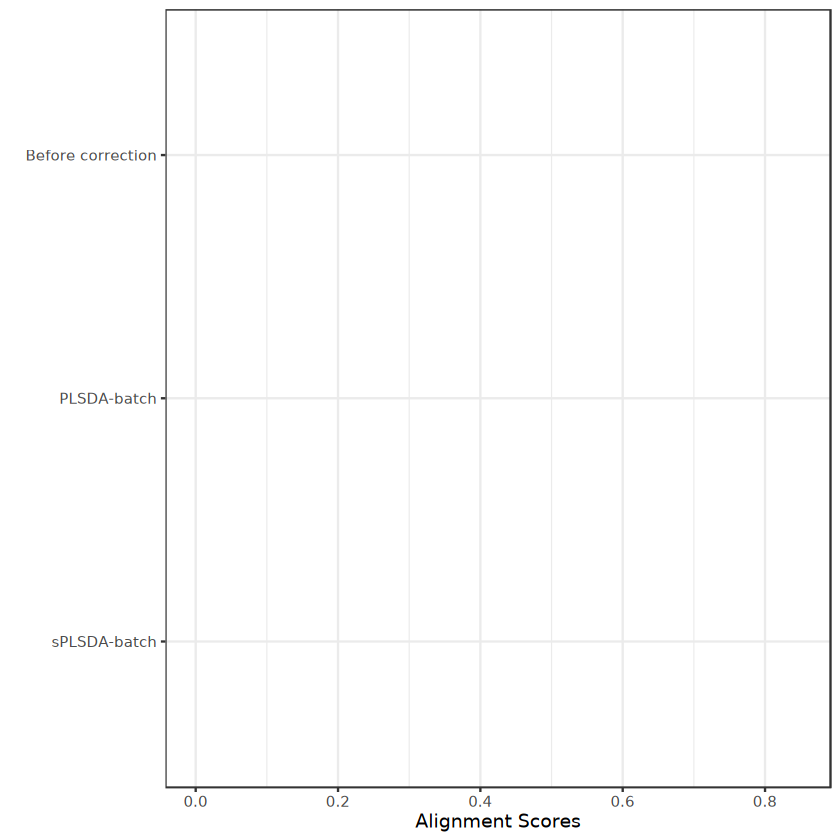

In [97]:
## ----ADalignment, fig.height = 3, out.width = '90%', fig.align = 'center', fig.cap = 'Comparison of alignment scores before and after batch effect correction using different methods for the AD data.'----
# AD data
ad.scores <- c()
names(ad.batch) <- rownames(ad.clr)
for(i in seq_len(length(ad.corrected.list))){
    res <- alignment_score(data = ad.corrected.list[[i]], 
                            batch = ad.batch, 
                            var = 0.95, 
                            k = 8, 
                            ncomp = 50)
    ad.scores <- c(ad.scores, res)
}

ad.scores.df <- data.frame(scores = ad.scores, 
                            methods = names(ad.corrected.list))

ad.scores.df$methods <- factor(ad.scores.df$methods, 
                                levels = rev(names(ad.corrected.list)))


ggplot() + geom_col(aes(x = ad.scores.df$methods, 
                        y = ad.scores.df$scores)) + 
    geom_text(aes(x = ad.scores.df$methods, 
                    y = ad.scores.df$scores/2, 
                    label = round(ad.scores.df$scores, 3)), 
                size = 3, col = 'white') + 
    coord_flip() + theme_bw() + ylab('Alignment Scores') + 
    xlab('') + ylim(0,0.85)


            methods scores
1 Before correction     NA
2       PLSDA-batch     NA
3      sPLSDA-batch     NA


Warning message in min(x):
“no non-missing arguments to min; returning Inf”
Warning message in max(x):
“no non-missing arguments to max; returning -Inf”


Range(scores):  Inf to -Inf 
NAs:  3 


Coordinate system already present. Adding new coordinate system, which will
replace the existing one.
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_col()`).”


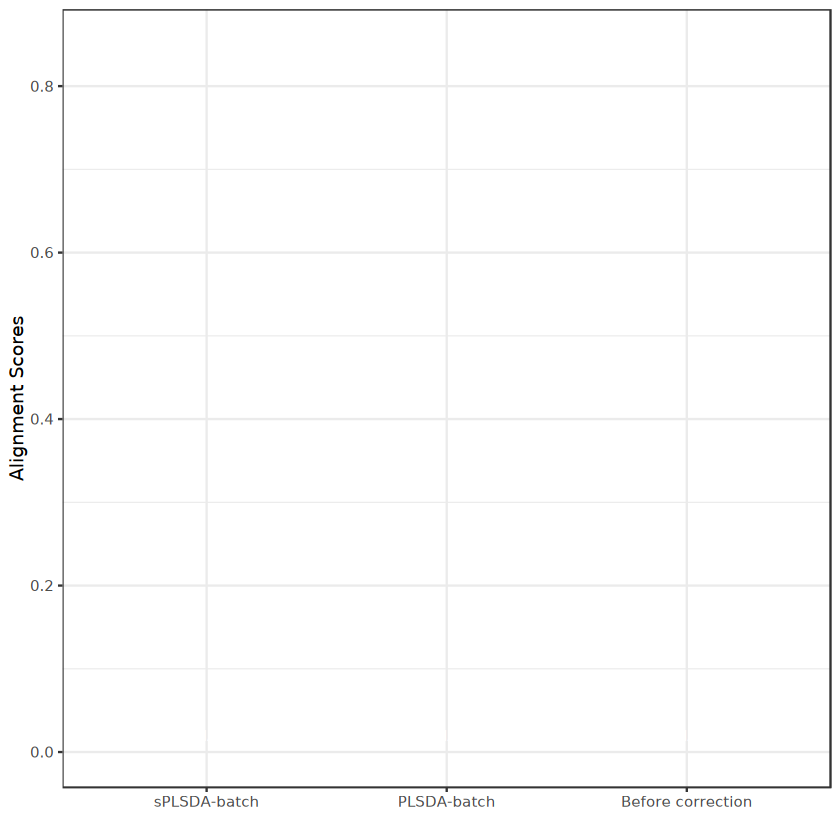

In [98]:
library(ggplot2)

# 1) Compute alignment scores safely, aligning batch to each matrix
score_list <- lapply(names(ad.corrected.list), function(meth) {
  X <- ad.corrected.list[[meth]]
  # align batch to the rows of X
  stopifnot(!is.null(rownames(X)))
  b <- ad.batch[rownames(X)]
  if (any(is.na(b))) {
    missing_ids <- rownames(X)[is.na(b)]
    stop("Batch factor missing for samples: ", paste(head(missing_ids, 10), collapse=", "))
  }
  tryCatch(
    alignment_score(data = X, batch = b, var = 0.95, k = 8, ncomp = 50),
    error = function(e) NA_real_
  )
})
names(score_list) <- names(ad.corrected.list)

# 2) Build the data.frame
ad.scores.df <- data.frame(
  methods = names(score_list),
  scores  = as.numeric(unlist(score_list)),
  stringsAsFactors = FALSE
)

# Optional: order factor
ad.scores.df$methods <- factor(ad.scores.df$methods,
                               levels = rev(names(ad.corrected.list)))

# 3) Quick diagnostics
print(ad.scores.df)
cat("Range(scores): ", paste(range(ad.scores.df$scores, na.rm = TRUE), collapse=" to "), "\n")
cat("NAs: ", sum(is.na(ad.scores.df$scores)), "\n")

# 4) Plot without dropping out-of-range; label NAs explicitly
ggplot(ad.scores.df, aes(x = methods, y = scores)) +
  geom_col() +
  geom_text(aes(label = ifelse(is.na(scores), "NA", round(scores, 3)),
                y = ifelse(is.na(scores), 0.02, scores/2)),
            size = 3, color = "white") +
  coord_flip() +
  theme_bw() +
  ylab("Alignment Scores") + xlab("") +
  coord_cartesian(ylim = c(0, 0.85))            # <- keeps bars, just clips view


In [99]:
## -----------------------------------------------------------------------------
splsda.plsda_batch <- splsda(X = ad.PLSDA_batch, Y = ad.trt, 
                            ncomp = 3, keepX = rep(50,3))
select.plsda_batch <- selectVar(splsda.plsda_batch, comp = 1)
head(select.plsda_batch$value)

splsda.splsda_batch <- splsda(X = ad.sPLSDA_batch, Y = ad.trt, 
                            ncomp = 3, keepX = rep(50,3))
select.splsda_batch <- selectVar(splsda.splsda_batch, comp = 1)
head(select.splsda_batch$value)

length(intersect(select.plsda_batch$name, select.splsda_batch$name))

,value.var
,<dbl>
CAACCCTGACGCAGCAACGCCGCGTGAAGGATGAAGGTTTTCGGATTGTAAACTTCTTTTCTCAGGGACGAAATTTGACGGTACCTGAGGAATAAGCTCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGAGCAAGCGTTGTCCGGATTTACTGGGTGTAAAGGGTGCGTAGGCGGCTTTGTAAGTCAGATGTGAAATCTATGGGCTCAACCCATAAACTGCATTTGAAACTACAGAGCTTGAGTGAAGTAGAGGCAGGCGGAATTCCCTGTGTAGCGGTGAAATGCGTAGAGATAGGGAGGAACACCAGTGGCGAAGGCGGCCTGCTGGGCTTTAACTGACGCTGAGGCACGAAAG,-0.4472195
AAAGCCTGACCCAGCGACGCCGCGTGAGGGAAGAAGGTCTTCGGATTGTAAACCTCTTTCAGCAGGGAAGAAGCAAGTGACGGTACCTGCAGAAGAAGTCACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCGAGCGTTATCCGGAATTACTGGGTGTAAAGGGTGTGTAGGCGGGGAAGCAAGTCAGATGTGAAATGTATGGGCTCAACTCATGCACTGCGTCTGAAACTGTTTCTCTTGAGAGTGGGAGAGGTAAACGGAATTCCCGGTGTAGCGGTGAAATGCGTAGATATCGGGAGGAACACCAGTGGCGAAGGCGGTTTACTGGACCATTACTGACGCTGAGACACGAAAG,-0.3352081
AGAGCCTGAACCAGCCAAGTAGCGTGAAGGAAGACTGCCCTATGGGTTGTAAACTTCTTTTGTTTGGGAATAAAGTCAGGCACGTGTGCCTGTTTGTATGTACCATTCGAATAAGCATCGGCTAATTCCGTGCCAGCAGCCGCGGTAATACGGAAGATGCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGGCTGTTAAGTCAGCGGTAAAATTTCCAGGCCCAACCTGGTCGTGCCGTTGAAACTGGCGGTCTTGAATGCACACAAGGGAGATGGAATTCGTCGTGTAGCGGTGAAATGCTTAGATATGACGAAGAACTCCGATTGCGAAGGCAGTCTCCTGGGGTGTAATTGACGCTGAGGCTCGAAAG,-0.2462219
GAAGCCTGATGCAGCAATGCCGCGTGAGGGAAGAAGGTCTTCGGATTGTAAACCTCTGTCATAAGGGAAGAAACAAGACTGTACCTTAGAAGGAAGCTCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGAGCGAGCGTTATCCGGAATTACTGGGTGTAAAGGGAGTGTAGGCGGGATTGTAAGTCAGATGTGAAAACTATGGGCTCAACTCATAGACTGCATTTGAAACTGCGATTCTTGAGTGAAGTAGAGGTAAGCGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACATCAGTGGCGAAGGCGGCTTACTGGGCTTTAACTGACGCTGAGGCTCGAAAG,-0.2438066
AAACCCTGATGCAGCGATGCCGCGTGGAGGAAGAAGGTTTTCGGATTGTAAACTCCTGTCTTAAAGGACGATAATGACGGTACTTTAGGAGGAAGCTCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGAGCGAGCGTTGTCCGGAATTACTGGGTGTAAAGGGAGCGTAGGCGGGACGGCAAGTCAGATGTGAAAACCATGGGCTCAACCTATGGACTGCATTTGAAACTGTTGTTCTTGAGTGAAGTAGAGGTAAGCGGAATTCCTGGTGTAGCGGTGAAATGCGTAGATATCAGGAGGAACACCGGTGGCGAAGGCGGCTTACTGGGCTTTAACTGACGCTGAGGCTCGAAAG,-0.2384766
AAAGCCTGATGCAGCAATGCCGCGTGAGGGAAGAAGGTCTTCGGATTGTAAACCTCTGTCATAAGGGAAGAAACAAGACTGTACCTTAGAAGGAAGCTCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGAGCGAGCGTTATCCGGAATTACTGGGTGTAAAGGGAGTGTAGGCGGGATTGTAAGTCAGATGTGAAAACTATGGGCTCAACTCATAGACTGCATTTGAAACTGCGATTCTTGAGTGAAGTAGAGGTAAGCGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACATCAGTGGCGAAGGCGGCTTACTGGGCTTTAACTGACGCTGAGGCTCGAAAG,-0.2243824


,value.var
,<dbl>
CAACCCTGACGCAGCAACGCCGCGTGAAGGATGAAGGTTTTCGGATTGTAAACTTCTTTTCTCAGGGACGAAATTTGACGGTACCTGAGGAATAAGCTCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGAGCAAGCGTTGTCCGGATTTACTGGGTGTAAAGGGTGCGTAGGCGGCTTTGTAAGTCAGATGTGAAATCTATGGGCTCAACCCATAAACTGCATTTGAAACTACAGAGCTTGAGTGAAGTAGAGGCAGGCGGAATTCCCTGTGTAGCGGTGAAATGCGTAGAGATAGGGAGGAACACCAGTGGCGAAGGCGGCCTGCTGGGCTTTAACTGACGCTGAGGCACGAAAG,-0.4618044
AAAGCCTGACCCAGCGACGCCGCGTGAGGGAAGAAGGTCTTCGGATTGTAAACCTCTTTCAGCAGGGAAGAAGCAAGTGACGGTACCTGCAGAAGAAGTCACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCGAGCGTTATCCGGAATTACTGGGTGTAAAGGGTGTGTAGGCGGGGAAGCAAGTCAGATGTGAAATGTATGGGCTCAACTCATGCACTGCGTCTGAAACTGTTTCTCTTGAGAGTGGGAGAGGTAAACGGAATTCCCGGTGTAGCGGTGAAATGCGTAGATATCGGGAGGAACACCAGTGGCGAAGGCGGTTTACTGGACCATTACTGACGCTGAGACACGAAAG,-0.3581782
GAAGCCTGATGCAGCAATGCCGCGTGAGGGAAGAAGGTCTTCGGATTGTAAACCTCTGTCATAAGGGAAGAAACAAGACTGTACCTTAGAAGGAAGCTCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGAGCGAGCGTTATCCGGAATTACTGGGTGTAAAGGGAGTGTAGGCGGGATTGTAAGTCAGATGTGAAAACTATGGGCTCAACTCATAGACTGCATTTGAAACTGCGATTCTTGAGTGAAGTAGAGGTAAGCGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACATCAGTGGCGAAGGCGGCTTACTGGGCTTTAACTGACGCTGAGGCTCGAAAG,-0.2719377
AAACCCTGATGCAGCGATGCCGCGTGGAGGAAGAAGGTTTTCGGATTGTAAACTCCTGTCTTAAAGGACGATAATGACGGTACTTTAGGAGGAAGCTCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGAGCGAGCGTTGTCCGGAATTACTGGGTGTAAAGGGAGCGTAGGCGGGACGGCAAGTCAGATGTGAAAACCATGGGCTCAACCTATGGACTGCATTTGAAACTGTTGTTCTTGAGTGAAGTAGAGGTAAGCGGAATTCCTGGTGTAGCGGTGAAATGCGTAGATATCAGGAGGAACACCGGTGGCGAAGGCGGCTTACTGGGCTTTAACTGACGCTGAGGCTCGAAAG,-0.2364164
AAAGCCTGATGCAGCAATGCCGCGTGAGGGAAGAAGGTCTTCGGATTGTAAACCTCTGTCATAAGGGAAGAAACAAGACTGTACCTTAGAAGGAAGCTCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGAGCGAGCGTTATCCGGAATTACTGGGTGTAAAGGGAGTGTAGGCGGGATTGTAAGTCAGATGTGAAAACTATGGGCTCAACTCATAGACTGCATTTGAAACTGCGATTCTTGAGTGAAGTAGAGGTAAGCGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACATCAGTGGCGAAGGCGGCTTACTGGGCTTTAACTGACGCTGAGGCTCGAAAG,-0.2320079
AGAGCCTGAACCAGCCAAGTAGCGTGAAGGAAGACTGCCCTATGGGTTGTAAACTTCTTTTGTTTGGGAATAAAGTCAGGCACGTGTGCCTGTTTGTATGTACCATTCGAATAAGCATCGGCTAATTCCGTGCCAGCAGCCGCGGTAATACGGAAGATGCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGGCTGTTAAGTCAGCGGTAAAATTTCCAGGCCCAACCTGGTCGTGCCGTTGAAACTGGCGGTCTTGAATGCACACAAGGGAGATGGAATTCGTCGTGTAGCGGTGAAATGCTTAGATATGACGAAGAACTCCGATTGCGAAGGCAGTCTCCTGGGGTGTAATTGACGCTGAGGCTCGAAAG,-0.2297153


[1] 44

In [100]:
saveRDS(ad.corrected.list$`PLSDA-batch`, "Haptoglobin_PLSDA_batch_corrected.rds")

In [48]:
# Fibrinogen

In [49]:
library(phyloseq)

# Example: counts matrix from phyloseq
ad.count <- as(otu_table(ps), "matrix")
if (taxa_are_rows(ps)) {
  ad.count <- t(ad.count)  # ensure samples in rows
}
dim(ad.count)

# Metadata (sample_data in phyloseq)
ad.metadata <- as.data.frame(sample_data(ps))

# Batch variable
ad.batch <- factor(ad.metadata$ExtractionDate, 
                   levels = unique(ad.metadata$ExtractionDate))

# Treatment variable
ad.trt <- as.factor(ad.metadata$Fibrinogen_InflamStat)

# Make sure names align with samples
names(ad.batch) <- names(ad.trt) <- rownames(ad.metadata)

# Quick check
table(ad.batch)
table(ad.trt)


[1]   142 21727

ad.batch
12/24/24 12/27/24  1/18/25  1/25/25   2/7/25   2/8/25 
      24       24       23       23       23       25 

ad.trt
Elevated   Normal 
      90       52 

In [50]:
ad.filter.res <- PreFL(data = ad.count)
ad.filter <- ad.filter.res$data.filter
dim(ad.filter)

# zero proportion before filtering
ad.filter.res$zero.prob
# zero proportion after filtering
sum(ad.filter == 0)/(nrow(ad.filter) * ncol(ad.filter))

[1]  142 1634

[1] 0.9941392

[1] 0.9333486

In [52]:
ad.clr <- logratio.transfo(X = ad.filter, logratio = 'CLR', offset = 1) 
class(ad.clr) = 'matrix'

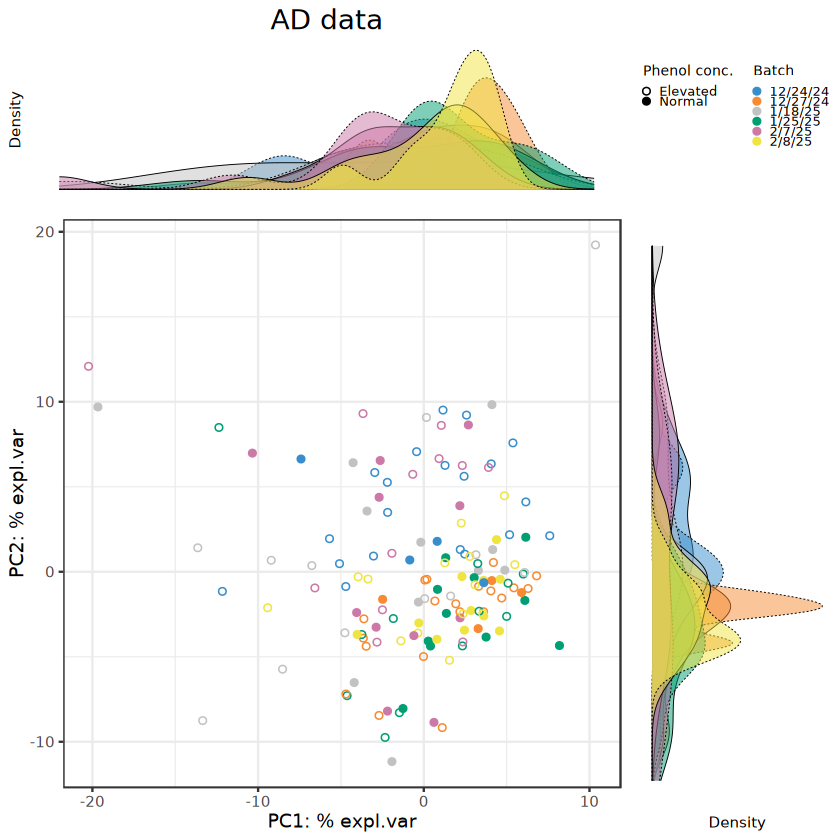

In [53]:
ad.pca.before <- pca(ad.clr, ncomp = 3, scale = TRUE)

Scatter_Density(object = ad.pca.before, batch = ad.batch, trt = ad.trt, 
                title = 'AD data', trt.legend.title = 'Phenol conc.')

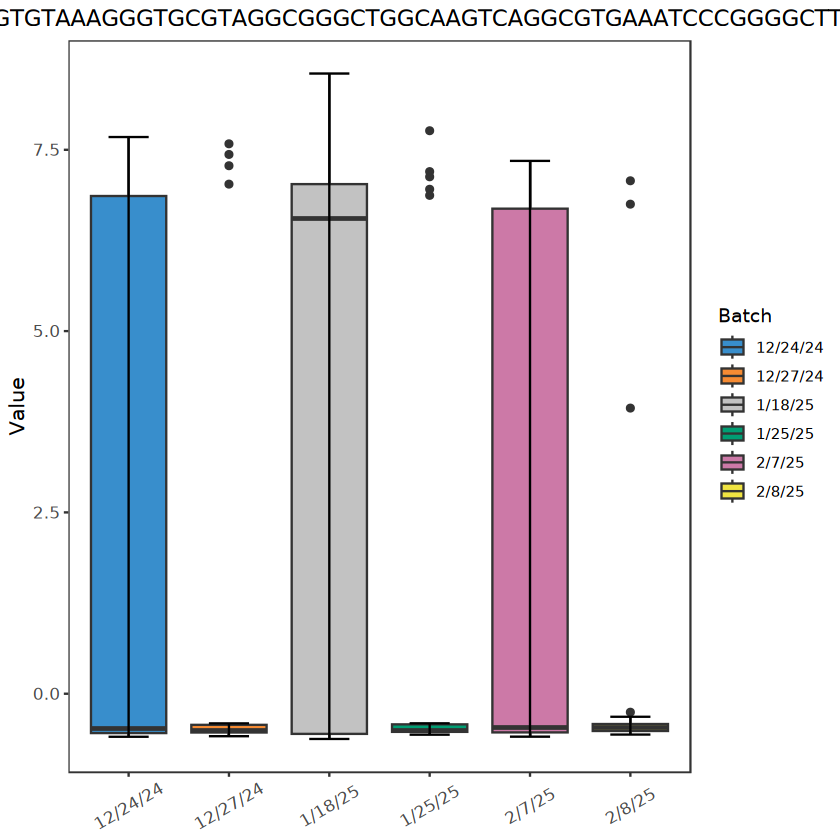

In [54]:
ad.OTU.name <- selectVar(ad.pca.before, comp = 1)$name[1]
ad.OTU_batch <- data.frame(value = ad.clr[,ad.OTU.name], batch = ad.batch)
box_plot(df = ad.OTU_batch, title = paste(ad.OTU.name, '(AD data)'), 
        x.angle = 30)

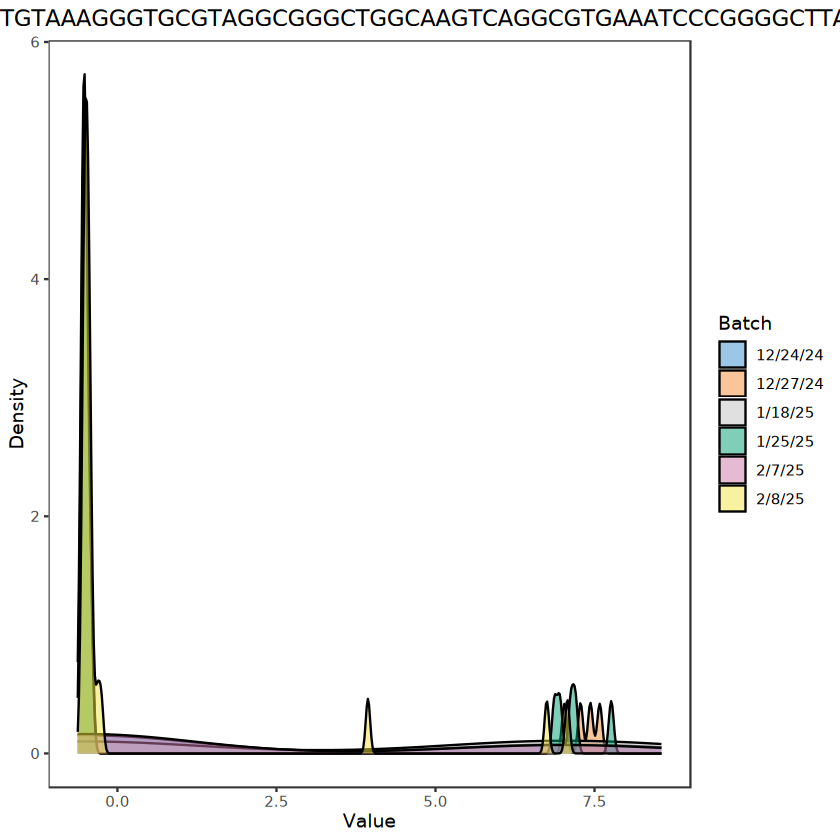

In [55]:
density_plot(df = ad.OTU_batch, title = paste(ad.OTU.name, '(AD data)'))

In [56]:
# reference batch: 12/24/24
ad.batch <- relevel(x = ad.batch, ref = '12/24/24')

ad.OTU.lm <- linear_regres(data = ad.clr[,ad.OTU.name], 
                            trt = ad.trt, batch.fix = ad.batch, 
                            type = 'linear model')
summary(ad.OTU.lm$model$data)


Call:
lm(formula = data[, i] ~ trt + batch.fix)

Residuals:
   Min     1Q Median     3Q    Max 
-4.524 -2.148 -1.240  3.131  6.999 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)   
(Intercept)         2.1673     0.6730   3.220   0.0016 **
trtNormal          -0.9796     0.5950  -1.646   0.1020   
batch.fix12/27/24  -1.2065     0.9414  -1.282   0.2022   
batch.fix1/18/25    1.7326     0.9695   1.787   0.0762 . 
batch.fix1/25/25   -0.5319     0.9695  -0.549   0.5841   
batch.fix2/7/25     0.0962     0.9695   0.099   0.9211   
batch.fix2/8/25    -1.4365     0.9460  -1.518   0.1312   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.261 on 135 degrees of freedom
Multiple R-squared:  0.1073,	Adjusted R-squared:  0.06764 
F-statistic: 2.705 on 6 and 135 DF,  p-value: 0.01639


In [57]:
# reference batch: 2/8/25
ad.batch <- relevel(x = ad.batch, ref = '2/8/25')

ad.OTU.lm <- linear_regres(data = ad.clr[,ad.OTU.name], 
                            trt = ad.trt, batch.fix = ad.batch, 
                            type = 'linear model')
summary(ad.OTU.lm$model$data)


Call:
lm(formula = data[, i] ~ trt + batch.fix)

Residuals:
   Min     1Q Median     3Q    Max 
-4.524 -2.148 -1.240  3.131  6.999 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)   
(Intercept)         0.7308     0.7028   1.040  0.30025   
trtNormal          -0.9796     0.5950  -1.646  0.10200   
batch.fix12/24/24   1.4365     0.9460   1.518  0.13123   
batch.fix12/27/24   0.2300     0.9460   0.243  0.80824   
batch.fix1/18/25    3.1691     0.9425   3.363  0.00101 **
batch.fix1/25/25    0.9046     0.9425   0.960  0.33889   
batch.fix2/7/25     1.5327     0.9425   1.626  0.10623   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 3.261 on 135 degrees of freedom
Multiple R-squared:  0.1073,	Adjusted R-squared:  0.06764 
F-statistic: 2.705 on 6 and 135 DF,  p-value: 0.01639


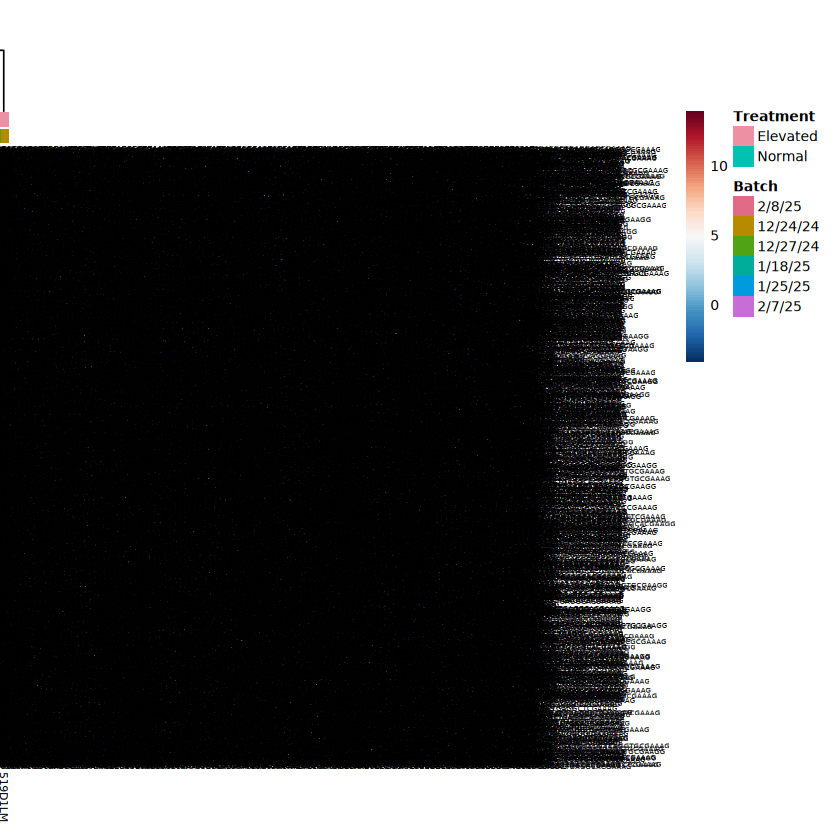

In [58]:
library(pheatmap)
library(RColorBrewer)

# ensure factors are clean
ad.batch <- droplevels(ad.batch)
ad.trt   <- droplevels(ad.trt)

# build colors safely
nbatch <- nlevels(ad.batch)
ntrt   <- nlevels(ad.trt)

batch_cols <- grDevices::hcl.colors(nbatch, palette = "Dark3")
trt_cols   <- grDevices::hcl.colors(ntrt,   palette = "Set2")

names(batch_cols) <- levels(ad.batch)
names(trt_cols)   <- levels(ad.trt)

ad.anno_colors <- list(Batch = batch_cols, Treatment = trt_cols)

# make sure annotation rows match heatmap columns
ad.anno_col <- data.frame(Batch = ad.batch, Treatment = ad.trt)
rownames(ad.anno_col) <- rownames(ad.metadata)  # or: colnames(ad.clr.ss)
stopifnot(identical(rownames(ad.anno_col), colnames(ad.clr.ss)))

# custom diverging palette (RdBu, reversed so blue=low, red=high)
heatmap_cols <- colorRampPalette(rev(brewer.pal(11, "RdBu")))(101)

# plot
pheatmap(
  ad.clr.ss,
  color = heatmap_cols,
  cluster_rows = FALSE,
  fontsize_row = 4,
  fontsize_col = 6,
  fontsize = 8,
  clustering_distance_rows = "euclidean",
  clustering_method = "ward.D",
  treeheight_row = 30,
  annotation_col = ad.anno_col,
  annotation_colors = ad.anno_colors,
  border_color = NA,
  main = "AD data - Scaled"
)


In [59]:
# AD data
ad.factors.df <- data.frame(trt = ad.trt, batch = ad.batch)
class(ad.clr) <- 'matrix'
ad.rda.before <- varpart(ad.clr, ~ trt, ~ batch, 
                        data = ad.factors.df, scale = TRUE)
ad.rda.before$part$indfract


,Df,R.squared,Adj.R.squared,Testable
,<dbl>,<lgl>,<dbl>,<lgl>
[a] = X1|X2,1,NA,0.0005393619,TRUE
[b] = X2|X1,5,NA,0.0042331390,TRUE
[c],0,NA,0.0000661963,FALSE
[d] = Residuals,NA,NA,0.9951613028,FALSE


In [60]:
# estimate the number of treatment components
ad.trt.tune <- plsda(X = ad.clr, Y = ad.trt, ncomp = 5)
ad.trt.tune$prop_expl_var #1

NULL

In [61]:
# estimate the number of batch components
ad.batch.tune <- PLSDA_batch(X = ad.clr, 
                            Y.trt = ad.trt, Y.bat = ad.batch,
                            ncomp.trt = 1, ncomp.bat = 10)
ad.batch.tune$explained_variance.bat #4
sum(ad.batch.tune$explained_variance.bat$Y[seq_len(4)])

$X
     comp 1      comp 2      comp 3      comp 4      comp 5      comp 6 
0.012813329 0.010506957 0.009739125 0.009122926 0.007589715 0.010502948 
     comp 7      comp 8      comp 9     comp 10 
0.008128559 0.009420238 0.008486305 0.008495618 

$Y
   comp 1    comp 2    comp 3    comp 4    comp 5    comp 6    comp 7    comp 8 
0.1997132 0.1989896 0.2003037 0.2012050 0.1997885 0.2002899 0.1995748 0.1964945 
   comp 9   comp 10 
0.1995173 0.2006314

[1] 0.8002115

In [62]:
## -----------------------------------------------------------------------------
ad.sPLSDA_batch.res <- PLSDA_batch(X = ad.clr, 
                                Y.trt = ad.trt, Y.bat = ad.batch,
                                ncomp.trt = 1, keepX.trt = 100,
                                ncomp.bat = 4)
ad.sPLSDA_batch <- ad.sPLSDA_batch.res$X.nobatch

## -----------------------------------------------------------------------------
ad.pca.before <- pca(ad.clr, ncomp = 3, scale = TRUE)
ad.pca.PLSDA_batch <- pca(ad.PLSDA_batch, ncomp = 3, scale = TRUE)
ad.pca.sPLSDA_batch <- pca(ad.sPLSDA_batch, ncomp = 3, scale = TRUE)

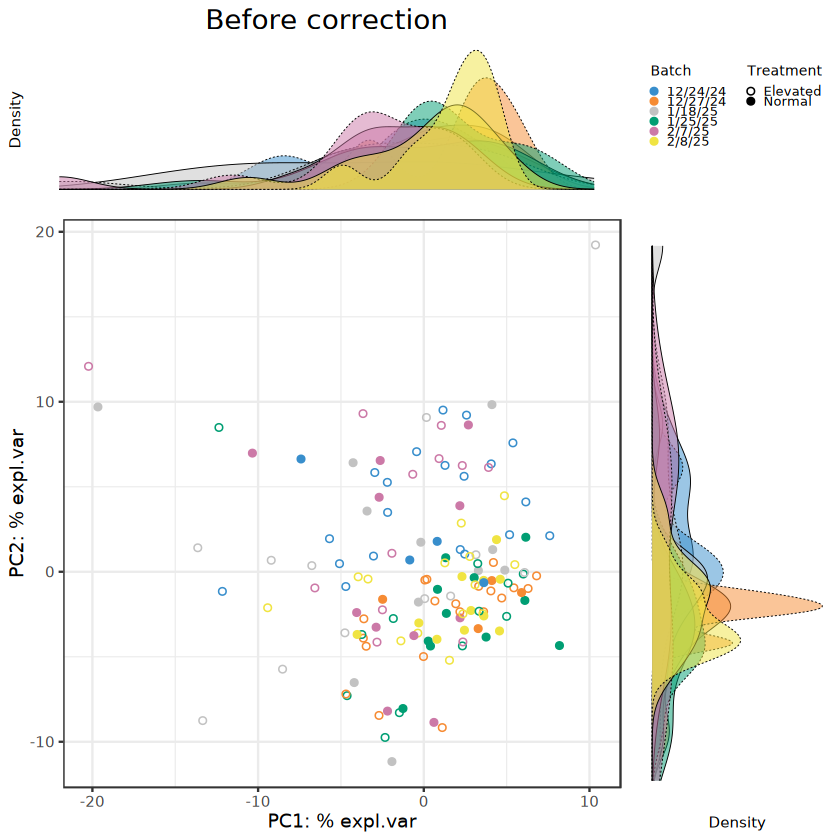

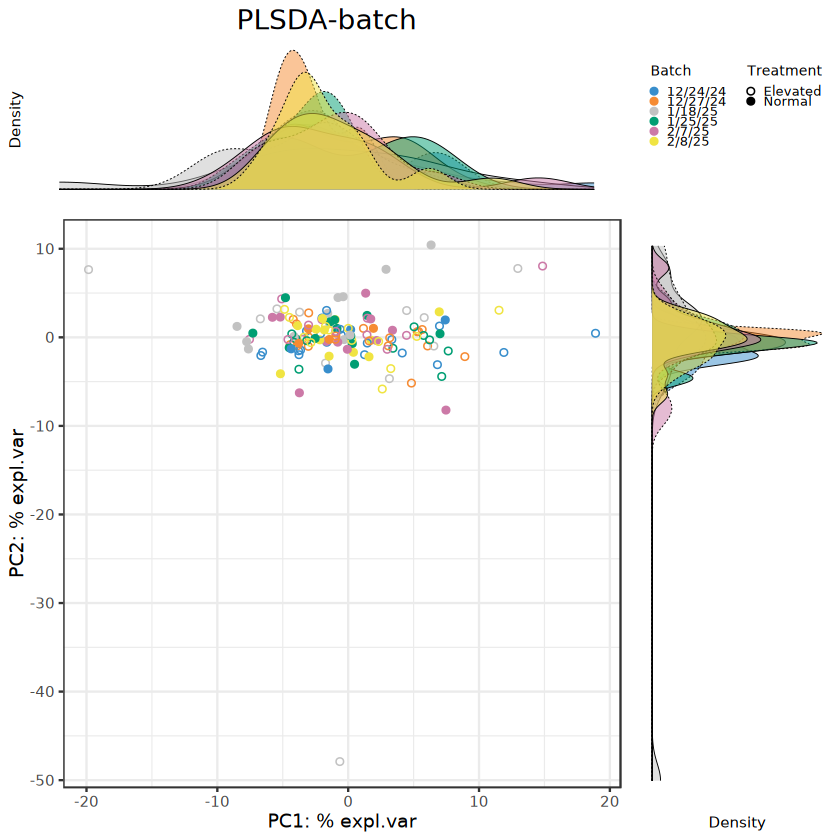

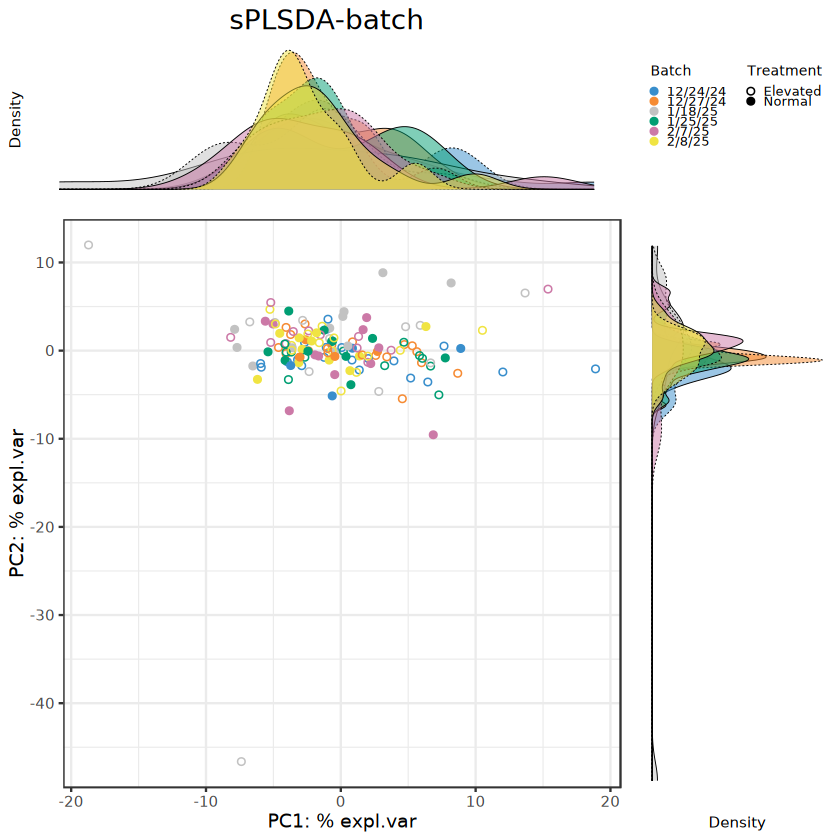

In [63]:
## ----fig.show='hide'----------------------------------------------------------
# order batches
ad.batch = factor(ad.metadata$ExtractionDate, 
                levels = unique(ad.metadata$ExtractionDate))

ad.pca.before.plot <- Scatter_Density(object = ad.pca.before, 
                                    batch = ad.batch, 
                                    trt = ad.trt, 
                                    title = 'Before correction')
ad.pca.PLSDA_batch.plot <- Scatter_Density(object = ad.pca.PLSDA_batch, 
                                        batch = ad.batch, 
                                        trt = ad.trt, 
                                        title = 'PLSDA-batch')
ad.pca.sPLSDA_batch.plot <- Scatter_Density(object = ad.pca.sPLSDA_batch, 
                                            batch = ad.batch, 
                                            trt = ad.trt, 
                                            title = 'sPLSDA-batch')

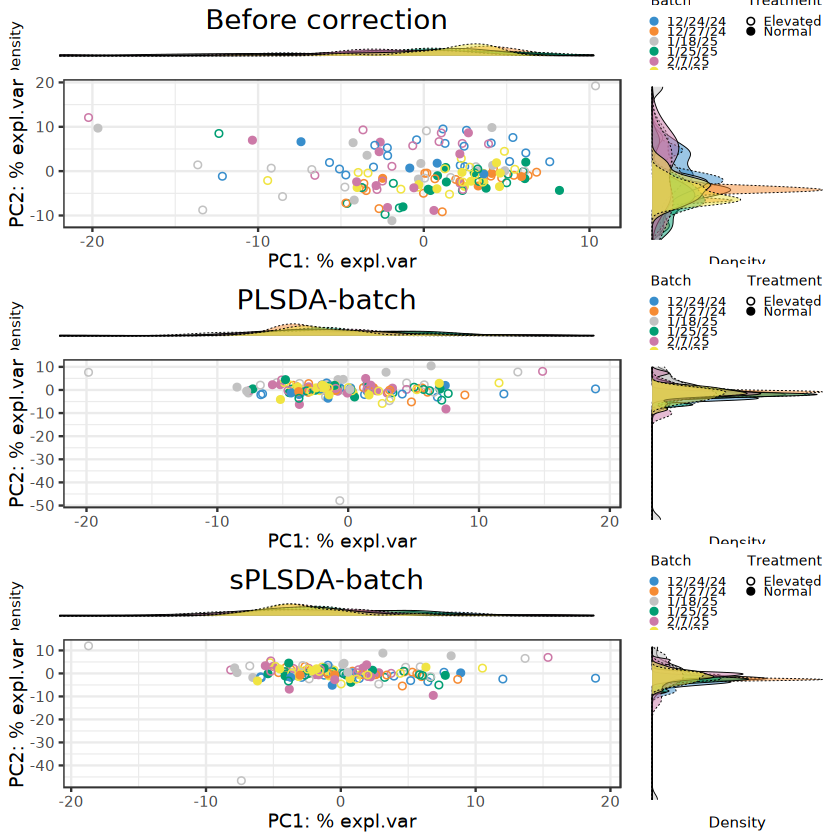

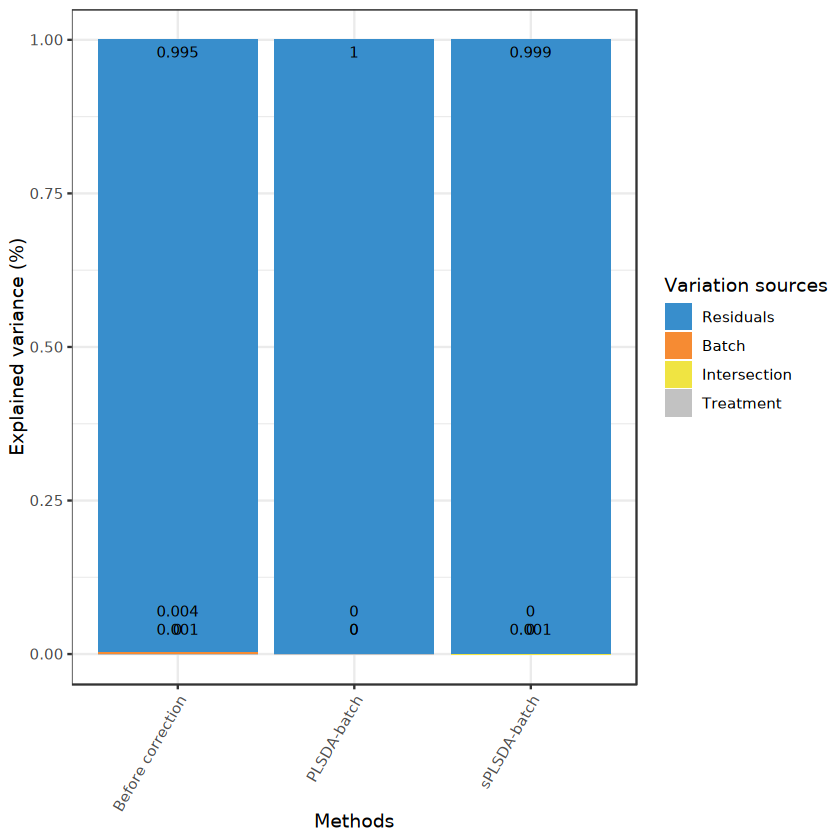

In [64]:
## ----ADpca, fig.height = 12, fig.width = 6, out.width = '80%', echo = FALSE, fig.align = 'center', fig.cap = 'The PCA sample plots with densities before and after batch effect correction in the AD data.'----
grid.arrange(ad.pca.before.plot, 
            ad.pca.PLSDA_batch.plot, 
            ad.pca.sPLSDA_batch.plot, ncol = 1)

## ----ADprda, fig.height = 6, fig.width = 4, out.width = '80%', fig.align = 'center', fig.cap = 'Global explained variance before and after batch effect correction for the AD data.'----
# AD data
ad.corrected.list <- list(`Before correction` = ad.clr, 
                        `PLSDA-batch` = ad.PLSDA_batch, 
                        `sPLSDA-batch` = ad.sPLSDA_batch)

ad.prop.df <- data.frame(Treatment = NA, Batch = NA, 
                        Intersection = NA, 
                        Residuals = NA) 
for(i in seq_len(length(ad.corrected.list))){
    rda.res = varpart(ad.corrected.list[[i]], ~ trt, ~ batch,
                    data = ad.factors.df, scale = TRUE)
    ad.prop.df[i, ] <- rda.res$part$indfract$Adj.R.squared}

rownames(ad.prop.df) = names(ad.corrected.list)

ad.prop.df <- ad.prop.df[, c(1,3,2,4)]

ad.prop.df[ad.prop.df < 0] = 0
ad.prop.df <- as.data.frame(t(apply(ad.prop.df, 1, 
                                    function(x){x/sum(x)})))

partVar_plot(prop.df = ad.prop.df)

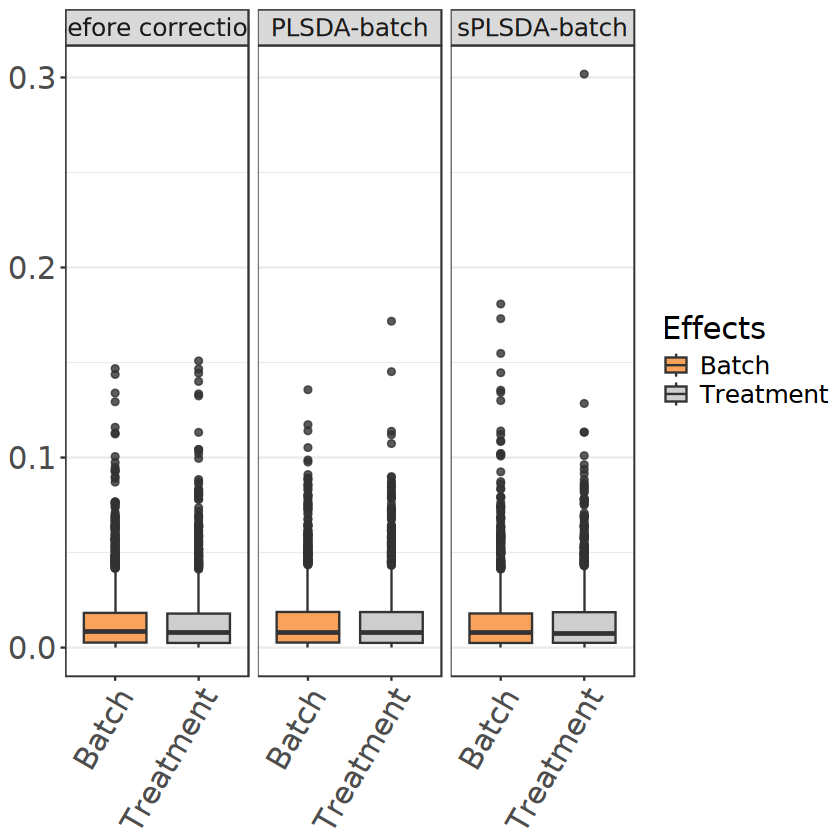

In [66]:
## ----ADr21, fig.height = 6, fig.width = 8, out.width = '100%', fig.align = 'center', fig.cap = 'AD study: $R^2$ values for each microbial variable before and after batch effect correction.'----
# AD data
# scale
ad.corr_scale.list <- lapply(ad.corrected.list, 
                            function(x){apply(x, 2, scale)})

ad.r_values.list <- list()
for(i in seq_len(length(ad.corr_scale.list))){
    ad.r_values <- data.frame(trt = NA, batch = NA)
    for(c in seq_len(ncol(ad.corr_scale.list[[i]]))){
        ad.fit.res.trt <- lm(ad.corr_scale.list[[i]][,c] ~ ad.trt)
        ad.r_values[c,1] <- summary(ad.fit.res.trt)$r.squared
        ad.fit.res.batch <- lm(ad.corr_scale.list[[i]][,c] ~ ad.batch)
        ad.r_values[c,2] <- summary(ad.fit.res.batch)$r.squared
    }
    ad.r_values.list[[i]] <- ad.r_values
}
names(ad.r_values.list) <- names(ad.corr_scale.list)

ad.boxp.list <- list()
for(i in seq_len(length(ad.r_values.list))){
    ad.boxp.list[[i]] <- 
        data.frame(r2 = c(ad.r_values.list[[i]][ ,'trt'],
                        ad.r_values.list[[i]][ ,'batch']), 
                    Effects = as.factor(rep(c('Treatment','Batch') 
                                        )))
}
names(ad.boxp.list) <- names(ad.r_values.list)

ad.r2.boxp <- rbind(ad.boxp.list$`Before correction`,
                    ad.boxp.list$removeBatchEffect,
                    ad.boxp.list$ComBat,
                    ad.boxp.list$`PLSDA-batch`,
                    ad.boxp.list$`sPLSDA-batch`,
                    ad.boxp.list$`Percentile Normalisation`,
                    ad.boxp.list$RUVIII)

ad.r2.boxp$methods <- rep(c('Before correction', 'PLSDA-batch', 'sPLSDA-batch')
                        )

ad.r2.boxp$methods <- factor(ad.r2.boxp$methods, 
                            levels = unique(ad.r2.boxp$methods))

ggplot(ad.r2.boxp, aes(x = Effects, y = r2, fill = Effects)) +
    geom_boxplot(alpha = 0.80) +
    theme_bw() + 
    theme(text = element_text(size = 18),
            axis.title.x = element_blank(),
            axis.title.y = element_blank(),
            axis.text.x = element_text(angle = 60, hjust = 1, size = 18),
            axis.text.y = element_text(size = 18),
            panel.grid.minor.x = element_blank(),
            panel.grid.major.x = element_blank(),
            legend.position = "right") + facet_grid( ~ methods) + 
    scale_fill_manual(values=pb_color(c(12,14))) 


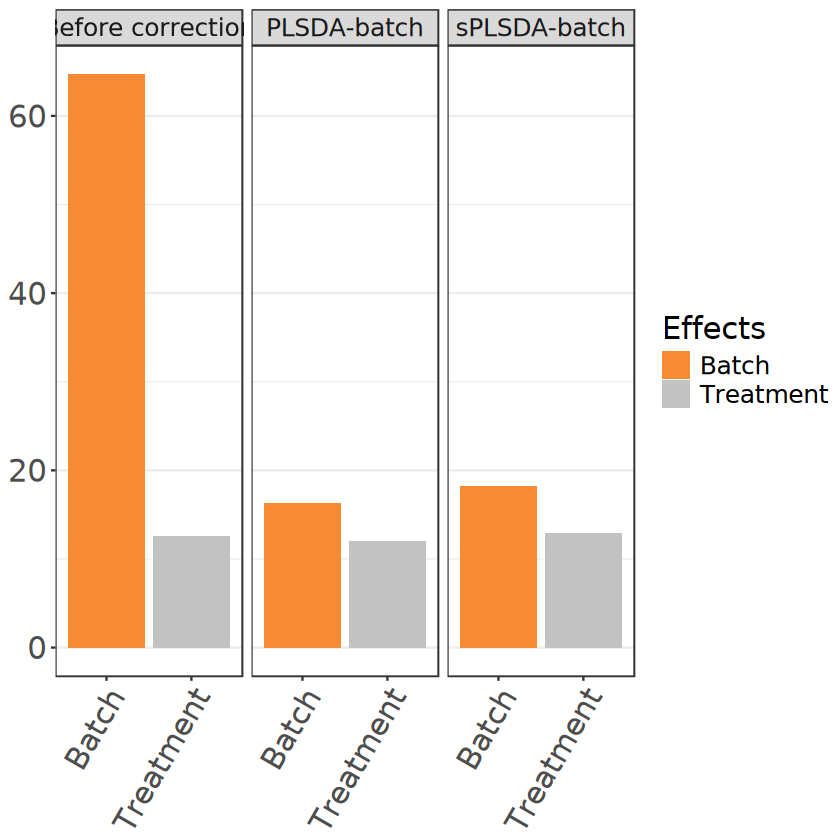

In [67]:
## ----ADr22, fig.height = 6, fig.width = 8, out.width = '100%', fig.align = 'center', fig.cap = 'AD study: the sum of $R^2$ values for each microbial variable before and after batch effect correction.'----
##################################
ad.barp.list <- list()
for(i in seq_len(length(ad.r_values.list))){
    ad.barp.list[[i]] <- data.frame(r2 = c(sum(ad.r_values.list[[i]][ ,'trt']),
                                        sum(ad.r_values.list[[i]][ ,'batch'])), 
                                    Effects = c('Treatment','Batch'))
}
names(ad.barp.list) <- names(ad.r_values.list)

ad.r2.barp <- rbind(ad.barp.list$`Before correction`,
                    ad.barp.list$removeBatchEffect,
                    ad.barp.list$ComBat,
                    ad.barp.list$`PLSDA-batch`,
                    ad.barp.list$`sPLSDA-batch`,
                    ad.barp.list$`Percentile Normalisation`,
                    ad.barp.list$RUVIII)


ad.r2.barp$methods <- rep(c('Before correction', 'PLSDA-batch', 'sPLSDA-batch'),
                        each = 2)

ad.r2.barp$methods <- factor(ad.r2.barp$methods, 
                            levels = unique(ad.r2.barp$methods))


ggplot(ad.r2.barp, aes(x = Effects, y = r2, fill = Effects)) +
    geom_bar(stat="identity") + 
    theme_bw() + 
    theme(text = element_text(size = 18),
            axis.title.x = element_blank(),
            axis.title.y = element_blank(),
            axis.text.x = element_text(angle = 60, hjust = 1, size = 18),
            axis.text.y = element_text(size = 18),
            panel.grid.minor.x = element_blank(),
            panel.grid.major.x = element_blank(),
            legend.position = "right") + facet_grid( ~ methods) + 
    scale_fill_manual(values=pb_color(c(12,14)))


Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_col()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_text()`).”


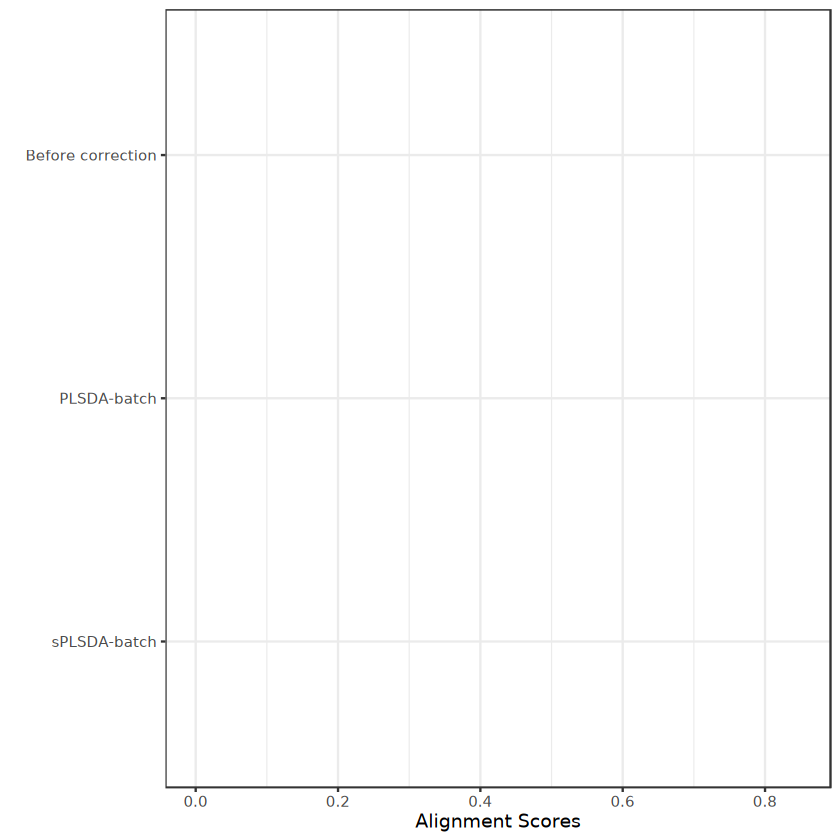

In [68]:
## ----ADalignment, fig.height = 3, out.width = '90%', fig.align = 'center', fig.cap = 'Comparison of alignment scores before and after batch effect correction using different methods for the AD data.'----
# AD data
ad.scores <- c()
names(ad.batch) <- rownames(ad.clr)
for(i in seq_len(length(ad.corrected.list))){
    res <- alignment_score(data = ad.corrected.list[[i]], 
                            batch = ad.batch, 
                            var = 0.95, 
                            k = 8, 
                            ncomp = 50)
    ad.scores <- c(ad.scores, res)
}

ad.scores.df <- data.frame(scores = ad.scores, 
                            methods = names(ad.corrected.list))

ad.scores.df$methods <- factor(ad.scores.df$methods, 
                                levels = rev(names(ad.corrected.list)))


ggplot() + geom_col(aes(x = ad.scores.df$methods, 
                        y = ad.scores.df$scores)) + 
    geom_text(aes(x = ad.scores.df$methods, 
                    y = ad.scores.df$scores/2, 
                    label = round(ad.scores.df$scores, 3)), 
                size = 3, col = 'white') + 
    coord_flip() + theme_bw() + ylab('Alignment Scores') + 
    xlab('') + ylim(0,0.85)

In [69]:
## -----------------------------------------------------------------------------
splsda.plsda_batch <- splsda(X = ad.PLSDA_batch, Y = ad.trt, 
                            ncomp = 3, keepX = rep(50,3))
select.plsda_batch <- selectVar(splsda.plsda_batch, comp = 1)
head(select.plsda_batch$value)

splsda.splsda_batch <- splsda(X = ad.sPLSDA_batch, Y = ad.trt, 
                            ncomp = 3, keepX = rep(50,3))
select.splsda_batch <- selectVar(splsda.splsda_batch, comp = 1)
head(select.splsda_batch$value)

length(intersect(select.plsda_batch$name, select.splsda_batch$name))

## -----------------------------------------------------------------------------
sessionInfo()

,value.var
,<dbl>
AGAGACTGAACCAGCCAAGTAGCGTGAAGGATGACTGCCCTACGGGTTGTAAACTTCTTTTGTTTGGGAATAAATGATACTACGTGTAGTATTTTGCATGTACCTTACGAATAAGCATCGGCTAATTCCGTGCCAGCAGCCGCGGTAATACGGAAGATGCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGGCTGTTAAGTCAGCGGTAAAATTTCCGGGCCCAACCCGGTCCTGCCGTTGAAACTGGCGGTCTTGAATGCACACAAGGGAGATGGAATTCGTCGTGTAGCGGTGAAATGCTTAGATATGACGAAGAACTCCGATTGCGAAGGCAGTCTCCTGGGGTGCTATTGACGCTGAGGCTCGAAAG,-0.3903519
AAAGCCTGACCCAGCAACGCCGCGTGAAGGAAGAAGGCCTTCGGGTTGTAAACTTCTTTTAGCAGGGACGAAGGACGTGACGGTACCTGCAGAAAAAGCAACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTTGCAAGCGTTGTCCGGATTTACTGGGTGTAAAGGGCGTGTAGGCGGAGATGCAAGTTGGGAGTGAAATCCCGGGGCTCAACCCCGGAACTGCTCTCAAAACTGTATCCCTTGAGTATCGGAGAGGCAAGCGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTGCTGGACGACAACTGACGCTGAGGCGCGAAAG,-0.3544687
AAAGCCTGATGGTGCGACGCCGCGTGGGGGAGGAAGGTCTTCGGATTGTAAACCCCTGTCATGTGGGAGCAAGACTTCGGTTTGATAGTACCACAAGAGGAAGAGACGGCAAACTCTGTGCCAGCAGCCGCGGTAATACAGAGGTCTCAAGCGTTGTTCGGAATCACTGGGCGTAAAGGGTACGTAGGCGGCGTCATAAGTCGTGCGTGAAAGGCAGGGGCTCAACCTCTGGAGTGCGCGTGATACTGTGATGCTGGAGTAATGGAGGGGGAACCGGAATTCTTGGTGTAGCAGTGAAATGCGTAGATATCAAGAAGAAGACTCGTGGCGAAGGCGGGTTCCTGGACATTTACTGACGCTGAGGTACGAAGG,0.3331054
CAACTCTGAACCAGCCAAGTAGCGTGCAGGATGACGGCCCTATGGGTTGTAAACTGCTTTTATGCGGGGATAAATGATCCTACGTGTAGGATTTTGCAGGTACCGCATGAATAAGGACCGGCTAATTCCGTGCCAGCAGCCGCGGTAATACGGAAGGTCCAGGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGCCTGTTAAGCGTGTTGTGAAATGTGGAGGCTCAACCTCTGCACTGCAGCGCGAACTGGCGGGCTTGAGTTGGCTGAAAGTATGCGGAATTCGTGGTGTAGCGGTGAAATGCTTAGATATCACGAAGAACTCCGATTGCGAAGGCAGCATGCTGTAGCCTTACTGACGCTGAAGCTCGAAGG,-0.3260441
AAACCCTGACCCAGCAACGCCGCGTGAAGGAAGAAGGCCTTCGGGTTGTAAACTTCTTTTACCAGGGACGAATAACGTGACGGTACCTGGAGAAAAAGCAACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTTGCAAGCGTTGTCCGGATTTACTGGGTGTAAAGGGCGTGTAGGCGGAGCTGCAAGTCAGATGTGAAATCCCGGGGCTCAACCCCGGAACTGCATTTGAAACTGTAGCCCTTGAGTATCGGAGAGGCAAGCGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTGCTGGACGACAACTGACGCTGAGGCGCGAAAG,-0.2835534
AAAGCCTGATGCAGCGACGCCGCGTGAAGGATGAAGTATTTCGGTATGTAAACTTCTATCAGCAGGGAAGAAAATGACGGTACCTGACTAAGAAGCCCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGCTTTGCAAGTCTGAAGTGAAAGGCATGGGCTCAACCTGTGGACTGCTTTGGAAACTGTGAAGCTAGAATGTCGGAGAGGCAAGGGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGCCTTGCTGGACGATGATTGACGTTGAGGCTCGAAAG,0.2755487


,value.var
,<dbl>
AAAGCCTGACCCAGCAACGCCGCGTGAAGGAAGAAGGCCTTCGGGTTGTAAACTTCTTTTAGCAGGGACGAAGGACGTGACGGTACCTGCAGAAAAAGCAACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTTGCAAGCGTTGTCCGGATTTACTGGGTGTAAAGGGCGTGTAGGCGGAGATGCAAGTTGGGAGTGAAATCCCGGGGCTCAACCCCGGAACTGCTCTCAAAACTGTATCCCTTGAGTATCGGAGAGGCAAGCGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGGCTTGCTGGACGACAACTGACGCTGAGGCGCGAAAG,-0.3904090
AAAGCCTGATGGTGCGACGCCGCGTGGGGGAGGAAGGTCTTCGGATTGTAAACCCCTGTCATGTGGGAGCAAGACTTCGGTTTGATAGTACCACAAGAGGAAGAGACGGCAAACTCTGTGCCAGCAGCCGCGGTAATACAGAGGTCTCAAGCGTTGTTCGGAATCACTGGGCGTAAAGGGTACGTAGGCGGCGTCATAAGTCGTGCGTGAAAGGCAGGGGCTCAACCTCTGGAGTGCGCGTGATACTGTGATGCTGGAGTAATGGAGGGGGAACCGGAATTCTTGGTGTAGCAGTGAAATGCGTAGATATCAAGAAGAAGACTCGTGGCGAAGGCGGGTTCCTGGACATTTACTGACGCTGAGGTACGAAGG,0.3473621
CAACTCTGAACCAGCCAAGTAGCGTGAGGGATGACTGCCCTACGGGTTGTAAACCTCTTTTGTCGGGGAATAAACCGCGCCACGTGTGGCGCCCTGCATGTACCCGCAGAATAAGGACCGGCTAATTCCGTGCCAGCAGCCGCGGTAATACGGAAGGTCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGGCTGTTAAGCCAGCCGTCAAATTGCGGGGCTCAACCCCGTACCGCGGTTGGAACTGGCGGCCTTGAGTCGGCAAGAGGCGCGTGGAATTCGTGGTGTAGCGGTGAAATGCATAGATATCACGAGGAACTCCGATTGCGAAGGCAGCGCGCTGGGGCCGTACTGACGCTGATGCTCGAAGG,-0.3268713
AAAGCCTGATGCAGCGACGCCGCGTGAAGGATGAAGTATTTCGGTATGTAAACTTCTATCAGCAGGGAAGAAAATGACGGTACCTGACTAAGAAGCCCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGCTTTGCAAGTCTGAAGTGAAAGGCATGGGCTCAACCTGTGGACTGCTTTGGAAACTGTGAAGCTAGAATGTCGGAGAGGCAAGGGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGCCTTGCTGGACGATGATTGACGTTGAGGCTCGAAAG,0.3103758
AAACCCTGATGCAGCGACGCCGCGTGAGTGAAGAAGTATTTCGGTACGTAAAGCTCTATCAGCAGGGAAGAAAATGACGGTACCTGACTAAGAAGCCCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGCTTTGCAAGTCTGAAGTGAAAGCCCGGGGCTCAACCCCGGGACTGCTTTGGAAACTGTAGAGCTAGAGTGCAGGAGAGGTAAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTGGCGAAGGCGTCTTACTGGACTGTAACTGACGTTGAGGCTCGAAAG,-0.2887389
AGAGACTGAACCAGCCAAGTAGCGTGAAGGATGACTGCCCTACGGGTTGTAAACTTCTTTTGTTTGGGAATAAATGATACTACGTGTAGTATTTTGCATGTACCTTACGAATAAGCATCGGCTAATTCCGTGCCAGCAGCCGCGGTAATACGGAAGATGCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGGCTGTTAAGTCAGCGGTAAAATTTCCGGGCCCAACCCGGTCCTGCCGTTGAAACTGGCGGTCTTGAATGCACACAAGGGAGATGGAATTCGTCGTGTAGCGGTGAAATGCTTAGATATGACGAAGAACTCCGATTGCGAAGGCAGTCTCCTGGGGTGCTATTGACGCTGAGGCTCGAAAG,-0.2216100


[1] 33

R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Rocky Linux 8.10 (Green Obsidian)

Matrix products: default
BLAS/LAPACK: /home/ldas/.conda/envs/r_env/lib/libopenblasp-r0.3.29.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Indianapolis
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] RColorBrewer_1.1-3              phyloseq_1.50.0                
 [3] PLSDAbatch_1.2.0                TreeSummarizedExperiment_2.14.0
 [5] Biostrings_2.74.1               XVector_0.46.0                 
 [7] SingleCellExperiment_1.28.0     SummarizedExperiment_1.36.0    
 [9] GenomicRanges_1.5

In [70]:
saveRDS(ad.corrected.list$`PLSDA-batch`, "Fibrinogen_PLSDA_batch_corrected.rds")